## Import of utils 

In [1]:
# Create folder 
from utils.create_folder import create_simulation_folder
results_dir = create_simulation_folder()

[INFO] Simulation folder created: results/2026-01-05_10-22-09


In [2]:
# =================================
# Global reproducibility seed
# =================================
GLOBAL_SEED = 42

import os
import random
import numpy as np

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)

In [3]:
import re

def safe_filename(text):
    """Convert any string into a safe filename."""
    text = text.lower()
    text = text.replace(" ", "_")
    text = re.sub(r"[^a-z0-9_\-]", "", text)  # keep only alphanum, _, -
    return text


## Topology

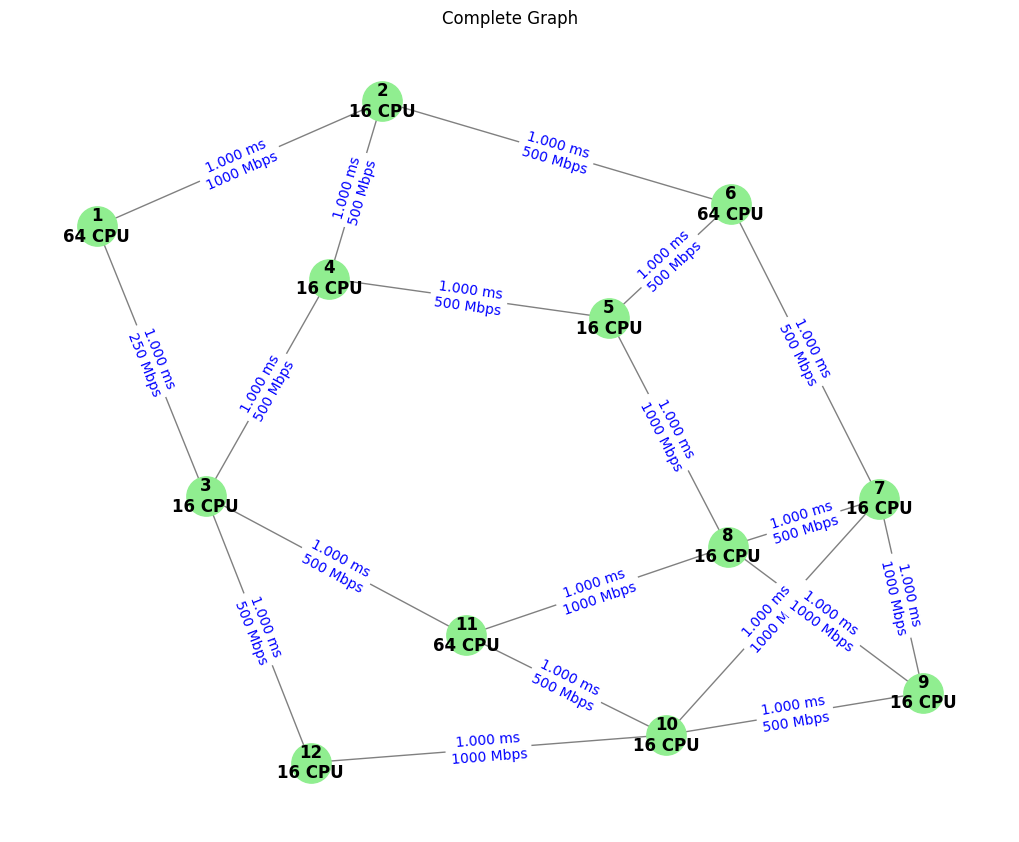

In [4]:
from utils.topology import topology_bayern, draw_graph, topologie_finlande, topology_brazil
from utils.generate_slices import generate_random_slices

from milp.topology_to_instance import build_instance_from_topology
from milp.solve_gurobi_sequential import solve_gurobi_shrink_until_feasible
from milp.adapter import MILPResultAdapterGurobi

import pandas as pd

# === Topology ===
G = topologie_finlande()
draw_graph(G)


# Scalability

In [5]:
# ============================
# FAST DEBUG CELL (runs quickly)
# ============================

import os
import time
import random
import numpy as np
import networkx as nx
import pandas as pd
from copy import deepcopy
from datetime import datetime
import re

# --- Safe filename function ---
def safe_filename(text):
    """Convert any string into a safe filename: no accents, spaces, or special chars."""
    text = text.lower()
    text = text.replace(" ", "_")
    text = re.sub(r"[^a-z0-9_\-]", "", text)
    return text

# --- Global reproducibility seed ---
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)

# --- MILP modules ---
from milp.create_instance import create_instance
from milp.solve_gurobi_sequential import solve_gurobi_shrink_until_feasible
from milp.adapter import MILPResultAdapterGurobi

# --- Topologies ---
from utils.topology import topologie_finlande

# --- Slice generation ---
from utils.generate_slices import generate_random_slices

# --- Graph generation ---
from utils.generate_graphs import plot_all_routes, plot_cpu_usage

# --- Heuristics ---
from heuristics.a_star import run_astar
from heuristics.run_abo_full_batch import run_abo_full_batch
from heuristics.run_fabo_full_batch import run_fabo_full_batch
from heuristics.best_fit import run_best_fit
from heuristics.first_fit import run_first_fit
from heuristics.a_star_energy_aware import energy_aware_astar

# --- Metrics ---
from utils.metrics import (
    count_accepted_slices,
    compute_energy_new,
    compute_total_bandwidth,
    compute_total_latency,
)

# ============================
# Directories for results
# ============================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_dir = os.path.join("./results", safe_filename(timestamp))
os.makedirs(results_dir, exist_ok=True)

routes_dir = os.path.join(results_dir, "routes")
cpu_dir = os.path.join(results_dir, "cpu_usage")
os.makedirs(routes_dir, exist_ok=True)
os.makedirs(cpu_dir, exist_ok=True)

print(f"[INFO] Results will be saved under: {results_dir}")

# ============================
# FAST parameters (smoke test)
# ============================

MILP_TIME_LIMIT = 30   # fast
ENTRY = 6

MAX_MILP_SLICES = 4
MAX_MILP_VNFS_TOTAL = 8

# --- Topology ---
G = topologie_finlande()
ENTRY = 6
pos = nx.spring_layout(G, seed=GLOBAL_SEED)

# --- VNF profiles (smaller list helps speed) ---
vnf_profiles = [
    {"cpu": 2, "throughput": 40, "latency": 120},
    {"cpu": 4, "throughput": 50, "latency": 180},
]

# --- Base capacities ---
node_capacity_base = {n: G.nodes[n]["cpu"] for n in G.nodes}
link_capacity_base = {(u, v): G[u][v]["bandwidth"] for u, v in G.edges}
link_capacity_base.update({(v, u): G[u][v]["bandwidth"] for u, v in G.edges})

link_latency = {(u, v): G[u][v]["latency"] for u, v in G.edges}
link_latency.update({(v, u): G[u][v]["latency"] for u, v in G.edges})

# --- Parameter grid (FAST DEBUG MODE) ---
param_grid = {
    "num_slices": [2, 3, 4],
    "num_vnfs_per_slice": [2],
    "seed": [1],
}

max_slices = max(param_grid["num_slices"])

# IMPORTANT: reset records before the main loop
records = []

try:
    # ------------------------------------------------------------------
    # Main experiment loop with a fixed pool of slices per (vnf, seed)
    # ------------------------------------------------------------------
    for num_vnfs in param_grid["num_vnfs_per_slice"]:
        for seed in param_grid["seed"]:
            random.seed(seed)
            np.random.seed(seed)

            print(
                f"\n[INFO] === Pre-generating slice pool: max_slices={max_slices}, "
                f"VNFs={num_vnfs}, seed={seed} ==="
            )

            slice_pool = generate_random_slices(
                G,
                vnf_profiles,
                num_slices=max_slices,
                num_vnfs_per_slice=num_vnfs,
                entry=ENTRY,
            )

            if len(slice_pool) < max_slices:
                print(f"[WARN] slice_pool has only {len(slice_pool)} entries (expected {max_slices}).")

            # Sweep number of slices for this (num_vnfs, seed)
            for num_slices in param_grid["num_slices"]:
                total_vnfs = num_slices * num_vnfs

                print(
                    f"\n[INFO] === Running Load Test: {num_slices} slices × "
                    f"{num_vnfs} VNFs (total={total_vnfs}), seed={seed} ==="
                )

                slices = deepcopy(slice_pool[:num_slices])
                method_results = {}
                method_times = {}

                # --- Heuristics ---
                for name, func, args in [
                    ("A*", run_astar, (G, slices, node_capacity_base, link_capacity_base)),
                    ("ABO", run_abo_full_batch, (G, slices, node_capacity_base, link_latency, link_capacity_base)),
                    ("FABO", run_fabo_full_batch, (G, slices, node_capacity_base, link_latency, link_capacity_base)),
                    ("Best Fit", run_best_fit, (G, slices, node_capacity_base, link_capacity_base, link_latency)),
                    ("First Fit", run_first_fit, (G, slices, node_capacity_base, link_capacity_base, link_latency)),
                    ("Energy-Aware A*", energy_aware_astar, (G, slices, node_capacity_base, link_capacity_base, 0.6, 0.4)),
                ]:
                    start = time.time()
                    try:
                        df_res, res_list = func(*args)
                        method_results[name] = res_list
                    except Exception as e:
                        print(f"[ERROR] {name} failed: {e}")
                        method_results[name] = []
                    method_times[name] = time.time() - start

                # --- MILP (FAST: global + shrink-until-feasible) ---
                if num_slices <= MAX_MILP_SLICES and total_vnfs <= MAX_MILP_VNFS_TOTAL:
                    try:
                        print(f"\n[INFO][MILP] Running Gurobi (shrink-until-feasible)…")
                        start = time.time()

                        instance = create_instance(G, slices)
                        instance.entry_node = ENTRY

                        out = solve_gurobi_shrink_until_feasible(
                            instance,
                            msg=False,
                            time_limit=MILP_TIME_LIMIT,
                        )

                        if out.get("last_result") is not None:
                            adapter = MILPResultAdapterGurobi(out["last_result"], instance)
                            method_results["MILP_Gurobi"] = [adapter]
                        else:
                            method_results["MILP_Gurobi"] = []

                        method_times["MILP_Gurobi"] = time.time() - start

                    except Exception as e:
                        print(f"[ERROR][MILP] Failed: {e}")
                        method_results["MILP_Gurobi"] = []
                        method_times["MILP_Gurobi"] = None

                # ----------------------------------------
                # Per-scenario visualizations (optional)
                # ----------------------------------------
                for method_name, result_list in method_results.items():
                    if not result_list:
                        continue

                    safe_img_name = safe_filename(
                        f"{method_name}_slices{num_slices}_vnfs{num_vnfs}_seed{seed}"
                    )

                    plot_all_routes(
                        G,
                        result_list,
                        title="All routed paths",
                        results_dir=routes_dir,
                        num_slices=num_slices,
                        num_vnfs_per_slice=num_vnfs,
                        seed=seed,
                        method_name=safe_img_name,
                        # pos=pos,  # uncomment if function supports fixed layout
                    )

                plot_cpu_usage(
                    G,
                    slices,
                    method_results,
                    results_dir=cpu_dir,
                    num_slices=num_slices,
                    num_vnfs_per_slice=num_vnfs,
                    seed=seed,
                )

                # --- Metrics ---
                for method_name, result_list in method_results.items():
                    if not result_list:
                        continue
                    try:
                        accepted = count_accepted_slices(result_list, slices)
                        total_energy = compute_energy_new(
                            result_list, slices, node_capacity_base, link_capacity_base
                        )
                        total_bw = sum(b for b in compute_total_bandwidth(result_list, slices) if b)
                        total_lat = sum(l for l in compute_total_latency(result_list, link_latency) if l)

                        records.append({
                            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                            "num_slices": num_slices,
                            "num_vnfs_per_slice": num_vnfs,
                            "total_vnfs": total_vnfs,
                            "seed": seed,
                            "method": method_name,
                            "accepted": accepted,
                            "total_energy": total_energy,
                            "total_bandwidth": total_bw,
                            "total_latency": total_lat,
                            "runtime_sec": method_times.get(method_name),
                        })
                    except Exception as e:
                        print(
                            f"[ERROR] Metrics failed for {method_name}, "
                            f"slices={num_slices}, vnfs={num_vnfs}, seed={seed}: {e}"
                        )

finally:
    # --- Save results even if something failed ---
    df_results = pd.DataFrame(records)

    if not df_results.empty:
        dup = df_results.groupby(["method", "num_slices", "num_vnfs_per_slice", "seed"]).size()
        print("[CHECK] Max repetitions:", dup.max())
    else:
        print("[WARN] df_results is empty, nothing to group.")

    output_path = os.path.join(results_dir, "scalability_results.csv")
    df_results.to_csv(output_path, index=False)

    print(f"\n[INFO] Results saved to {output_path}")
    print(f"[INFO] records generated: {len(records)}")
    print(f"[INFO] CSV exists? {os.path.exists(output_path)}")


[INFO] Results will be saved under: ./results/2026-01-05_10-28-22

[INFO] === Pre-generating slice pool: max_slices=4, VNFs=2, seed=1 ===

[INFO] === Running Load Test: 2 slices × 2 VNFs (total=4), seed=1 ===

[INFO][A*] === Solving slice 1 (VNFs=2, VLs=1) ===
[INFO][A*] Solution found after 6 expansions.
[SUMMARY][A*] Slice 1 accepted.


[INFO][A*] === Solving slice 2 (VNFs=2, VLs=1) ===
[INFO][A*] Solution found after 6 expansions.
[SUMMARY][A*] Slice 2 accepted.


[INFO][ABO] === Solving slice 1 (2 VNFs, 1 VLs) ===
[INFO][ABO] Found feasible solution after 10 states.
[SUMMARY][ABO] Slice 1 accepted. min_node_cpu=14, links_low_bw=0

[INFO][ABO] === Solving slice 2 (2 VNFs, 1 VLs) ===
[INFO][ABO] Found feasible solution after 10 states.
[SUMMARY][ABO] Slice 2 accepted. min_node_cpu=12, links_low_bw=0

[INFO][FABO] === Solving slice 1 (2 VNFs, 1 VLs) ===
[INFO][FABO] Found feasible solution after 10 states.
[SUMMARY][FABO] Slice 1 accepted. min_node_cpu=14, links_low_bw=0

[INFO][FABO]

/home/cecilia/5g-slicing-energy-effiiciency/simulator/utils/generate_graphs.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_a_slices2_vnfs2_seed1_s2_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_abo_slices2_vnfs2_seed1_s2_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_fabo_slices2_vnfs2_seed1_s2_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_best_fit_slices2_vnfs2_seed1_s2_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_first_fit_slices2_vnfs2_seed1_s2_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_energy-aware_a_slices2_vnfs2_seed1_s2_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_milp_gurobi_slices2_vnfs2_seed1_s2_v2_seed1.png
[INFO] Saved CPU utilization chart to ./results/2026-01-05_10-28-22/cpu_usage/cpu_utilization_s2_v2_seed1.png

[INFO] === Running Load Test: 3 slices × 2 VNFs (total=6), seed=1 ===

[INFO][A*] =

/home/cecilia/5g-slicing-energy-effiiciency/simulator/utils/generate_graphs.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_a_slices3_vnfs2_seed1_s3_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_abo_slices3_vnfs2_seed1_s3_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_fabo_slices3_vnfs2_seed1_s3_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_best_fit_slices3_vnfs2_seed1_s3_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_first_fit_slices3_vnfs2_seed1_s3_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_energy-aware_a_slices3_vnfs2_seed1_s3_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_milp_gurobi_slices3_vnfs2_seed1_s3_v2_seed1.png
[INFO] Saved CPU utilization chart to ./results/2026-01-05_10-28-22/cpu_usage/cpu_utilization_s3_v2_seed1.png

[INFO] === Running Load Test: 4 slices × 2 VNFs (total=8), seed=1 ===

[INFO][A*] =

/home/cecilia/5g-slicing-energy-effiiciency/simulator/utils/generate_graphs.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_a_slices4_vnfs2_seed1_s4_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_abo_slices4_vnfs2_seed1_s4_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_fabo_slices4_vnfs2_seed1_s4_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_best_fit_slices4_vnfs2_seed1_s4_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_first_fit_slices4_vnfs2_seed1_s4_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_energy-aware_a_slices4_vnfs2_seed1_s4_v2_seed1.png
[INFO] Saved route plot to ./results/2026-01-05_10-28-22/routes/routes_milp_gurobi_slices4_vnfs2_seed1_s4_v2_seed1.png
[INFO] Saved CPU utilization chart to ./results/2026-01-05_10-28-22/cpu_usage/cpu_utilization_s4_v2_seed1.png
[CHECK] Max repetitions: 1

[INFO] Results saved to ./results/2026-01-05_10-28-22/sc

In [18]:
# ============================
# FAST DEBUG CELL (CSV-only: routes + metrics)
# ============================

import os
import time
import random
import numpy as np
import networkx as nx
import pandas as pd
from copy import deepcopy
from datetime import datetime
import re

# --- Safe filename function ---
def safe_filename(text):
    # All comments in English
    text = str(text).lower()
    text = text.replace(" ", "_")
    text = re.sub(r"[^a-z0-9_\-]", "", text)
    return text

# --- Global reproducibility seed ---
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)

# --- MILP modules ---
from milp.create_instance import create_instance
from milp.solve_gurobi_sequential import solve_gurobi_shrink_until_feasible
from milp.adapter import MILPResultAdapterGurobi

# --- Topologies ---
from utils.topology import topologie_finlande

# --- Slice generation ---
from utils.generate_slices import generate_random_slices

# --- Heuristics ---
from heuristics.a_star import run_astar
from heuristics.run_abo_full_batch import run_abo_full_batch
from heuristics.run_fabo_full_batch import run_fabo_full_batch
from heuristics.best_fit import run_best_fit
from heuristics.first_fit import run_first_fit
from heuristics.a_star_energy_aware import energy_aware_astar

# --- Metrics ---
from utils.metrics import (
    count_accepted_slices,
    compute_energy_new,
    compute_total_bandwidth,
    compute_total_latency,
)

# ============================
# CSV exporters (routes)
# ============================

def _route_key_to_parts(vl_key):
    # All comments in English
    # Supports keys like (s, i, j) or (i, j)
    if isinstance(vl_key, tuple) and len(vl_key) == 3:
        s, i, j = vl_key
        return s, i, j
    if isinstance(vl_key, tuple) and len(vl_key) == 2:
        i, j = vl_key
        return None, i, j
    return None, None, None


def export_routes_to_rows(
    method_name,
    result_list,
    num_slices,
    num_vnfs_per_slice,
    seed,
    timestamp_str,
):
    # All comments in English
    rows = []
    for res_idx, res in enumerate(result_list):
        if not hasattr(res, "routed_vls") or res.routed_vls is None:
            continue

        for vl_key, path_nodes in res.routed_vls.items():
            s_id, vnf_src, vnf_dst = _route_key_to_parts(vl_key)

            if not path_nodes or len(path_nodes) < 2:
                continue

            path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))

            rows.append({
                "timestamp": timestamp_str,
                "method": method_name,
                "num_slices": num_slices,
                "num_vnfs_per_slice": num_vnfs_per_slice,
                "seed": seed,
                "result_idx": res_idx,
                "slice": s_id,
                "vnf_src": vnf_src,
                "vnf_dst": vnf_dst,
                "path_nodes": "->".join(map(str, path_nodes)),
                "path_edges": ";".join([f"{u}-{v}" for (u, v) in path_edges]),
                "num_hops": len(path_edges),
            })

    return rows


def export_milp_solution_to_rows(out, instance, method_name, num_slices, num_vnfs_per_slice, seed, timestamp_str):
    # All comments in English
    if out is None or out.get("last_result") is None:
        return []

    res = out["last_result"]
    vals = res.values
    rows = []

    # Placements: ("x", s, vnf_id, node)
    for key, val in vals.items():
        if not key or val <= 0.5:
            continue
        if key[0] == "x" and len(key) == 4:
            _, s, vnf_id, node = key
            rows.append({
                "timestamp": timestamp_str,
                "method": method_name,
                "num_slices": num_slices,
                "num_vnfs_per_slice": num_vnfs_per_slice,
                "seed": seed,
                "type": "placement",
                "slice": s,
                "vnf_src": vnf_id,
                "vnf_dst": None,
                "node": node,
                "u": None,
                "v": None,
                "path_nodes": None,
                "path_edges": None,
                "value": float(val),
            })

    # Flows: ("f", s, i, j, u, v)
    for key, val in vals.items():
        if not key or val <= 1e-9:
            continue
        if key[0] == "f" and len(key) == 6:
            _, s, i, j, u, v = key
            rows.append({
                "timestamp": timestamp_str,
                "method": method_name,
                "num_slices": num_slices,
                "num_vnfs_per_slice": num_vnfs_per_slice,
                "seed": seed,
                "type": "flow_edge",
                "slice": s,
                "vnf_src": i,
                "vnf_dst": j,
                "node": None,
                "u": u,
                "v": v,
                "path_nodes": None,
                "path_edges": None,
                "value": float(val),
            })

    # Slack: ("xi", s)
    for key, val in vals.items():
        if not key:
            continue
        if key[0] == "xi" and len(key) == 2:
            _, s = key
            rows.append({
                "timestamp": timestamp_str,
                "method": method_name,
                "num_slices": num_slices,
                "num_vnfs_per_slice": num_vnfs_per_slice,
                "seed": seed,
                "type": "xi",
                "slice": s,
                "vnf_src": None,
                "vnf_dst": None,
                "node": None,
                "u": None,
                "v": None,
                "path_nodes": None,
                "path_edges": None,
                "value": float(val),
            })

    return rows


# ============================
# Directories for results
# ============================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_dir = os.path.join("./results", safe_filename(timestamp))
os.makedirs(results_dir, exist_ok=True)

print(f"[INFO] Results will be saved under: {results_dir}")

# ============================
# FAST parameters (smoke test)
# ============================

MILP_TIME_LIMIT = 30
ENTRY = 6

MAX_MILP_SLICES = 4
MAX_MILP_VNFS_TOTAL = 8

# --- Topology ---
G = topologie_finlande()
ENTRY = 6

# --- VNF profiles ---
vnf_profiles = [
    {"cpu": 2, "throughput": 40, "latency": 120},
    {"cpu": 4, "throughput": 50, "latency": 180},
]

# --- Base capacities ---
node_capacity_base = {n: G.nodes[n]["cpu"] for n in G.nodes}
link_capacity_base = {(u, v): G[u][v]["bandwidth"] for u, v in G.edges}
link_capacity_base.update({(v, u): G[u][v]["bandwidth"] for u, v in G.edges})

link_latency = {(u, v): G[u][v]["latency"] for u, v in G.edges}
link_latency.update({(v, u): G[u][v]["latency"] for u, v in G.edges})

# --- Parameter grid (FAST DEBUG MODE) ---
param_grid = {
    "num_slices": [2, 3, 4],
    "num_vnfs_per_slice": [2],
    "seed": [1],
}

max_slices = max(param_grid["num_slices"])

# IMPORTANT: reset records before the main loop
records_metrics = []
records_routes = []
records_milp_raw = []

try:
    for num_vnfs in param_grid["num_vnfs_per_slice"]:
        for seed in param_grid["seed"]:
            random.seed(seed)
            np.random.seed(seed)

            print(
                f"\n[INFO] === Pre-generating slice pool: max_slices={max_slices}, "
                f"VNFs={num_vnfs}, seed={seed} ==="
            )

            slice_pool = generate_random_slices(
                G,
                vnf_profiles,
                num_slices=max_slices,
                num_vnfs_per_slice=num_vnfs,
                entry=ENTRY,
            )

            for num_slices in param_grid["num_slices"]:
                total_vnfs = num_slices * num_vnfs
                ts_now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

                print(
                    f"\n[INFO] === Running Load Test: {num_slices} slices × "
                    f"{num_vnfs} VNFs (total={total_vnfs}), seed={seed} ==="
                )

                slices = deepcopy(slice_pool[:num_slices])
                method_results = {}
                method_times = {}

                # --- Heuristics ---
                for name, func, args in [
                    ("A*", run_astar, (G, slices, node_capacity_base, link_capacity_base)),
                    ("ABO", run_abo_full_batch, (G, slices, node_capacity_base, link_latency, link_capacity_base)),
                    ("FABO", run_fabo_full_batch, (G, slices, node_capacity_base, link_latency, link_capacity_base)),
                    ("Best Fit", run_best_fit, (G, slices, node_capacity_base, link_capacity_base, link_latency)),
                    ("First Fit", run_first_fit, (G, slices, node_capacity_base, link_capacity_base, link_latency)),
                    ("Energy-Aware A*", energy_aware_astar, (G, slices, node_capacity_base, link_capacity_base, 0.6, 0.4)),
                ]:
                    start = time.time()
                    try:
                        _, res_list = func(*args)
                        method_results[name] = res_list
                    except Exception as e:
                        print(f"[ERROR] {name} failed: {e}")
                        method_results[name] = []
                    method_times[name] = time.time() - start

                # --- MILP (FAST: global + shrink-until-feasible) ---
                if num_slices <= MAX_MILP_SLICES and total_vnfs <= MAX_MILP_VNFS_TOTAL:
                    try:
                        print(f"[INFO][MILP] Running Gurobi (shrink-until-feasible)…")
                        start = time.time()

                        instance = create_instance(G, slices)
                        instance.entry_node = ENTRY

                        out = solve_gurobi_shrink_until_feasible(
                            instance,
                            msg=False,
                            time_limit=MILP_TIME_LIMIT,
                        )

                        if out.get("last_result") is not None:
                            adapter = MILPResultAdapterGurobi(out["last_result"], instance)
                            method_results["MILP_Gurobi"] = [adapter]
                            records_milp_raw.extend(
                                export_milp_solution_to_rows(
                                    out=out,
                                    instance=instance,
                                    method_name="MILP_Gurobi",
                                    num_slices=num_slices,
                                    num_vnfs_per_slice=num_vnfs,
                                    seed=seed,
                                    timestamp_str=ts_now,
                                )
                            )
                        else:
                            method_results["MILP_Gurobi"] = []

                        method_times["MILP_Gurobi"] = time.time() - start

                    except Exception as e:
                        print(f"[ERROR][MILP] Failed: {e}")
                        method_results["MILP_Gurobi"] = []
                        method_times["MILP_Gurobi"] = None

                # --- Export routes (ALL methods) ---
                for method_name, result_list in method_results.items():
                    if not result_list:
                        continue
                    records_routes.extend(
                        export_routes_to_rows(
                            method_name=method_name,
                            result_list=result_list,
                            num_slices=num_slices,
                            num_vnfs_per_slice=num_vnfs,
                            seed=seed,
                            timestamp_str=ts_now,
                        )
                    )

                # --- Metrics ---
                for method_name, result_list in method_results.items():
                    if not result_list:
                        continue
                    try:
                        accepted = count_accepted_slices(result_list, slices)
                        total_energy = compute_energy_new(
                            result_list, slices, node_capacity_base, link_capacity_base
                        )
                        total_bw = sum(b for b in compute_total_bandwidth(result_list, slices) if b)
                        total_lat = sum(l for l in compute_total_latency(result_list, link_latency) if l)

                        records_metrics.append({
                            "timestamp": ts_now,
                            "num_slices": num_slices,
                            "num_vnfs_per_slice": num_vnfs,
                            "total_vnfs": total_vnfs,
                            "seed": seed,
                            "method": method_name,
                            "accepted": accepted,
                            "total_energy": total_energy,
                            "total_bandwidth": total_bw,
                            "total_latency": total_lat,
                            "runtime_sec": method_times.get(method_name),
                        })
                    except Exception as e:
                        print(
                            f"[ERROR] Metrics failed for {method_name}, "
                            f"slices={num_slices}, vnfs={num_vnfs}, seed={seed}: {e}"
                        )

finally:
    # --- Save CSVs even if something failed ---
    df_metrics = pd.DataFrame(records_metrics)
    df_routes = pd.DataFrame(records_routes)
    df_milp_raw = pd.DataFrame(records_milp_raw)

    metrics_path = os.path.join(results_dir, "scalability_results.csv")
    routes_path = os.path.join(results_dir, "routes_all_methods.csv")
    milp_raw_path = os.path.join(results_dir, "milp_raw_vars.csv")

    df_metrics.to_csv(metrics_path, index=False)
    df_routes.to_csv(routes_path, index=False)
    df_milp_raw.to_csv(milp_raw_path, index=False)

    print(f"\n[INFO] Metrics CSV saved to: {metrics_path} (rows={len(df_metrics)})")
    print(f"[INFO] Routes  CSV saved to: {routes_path} (rows={len(df_routes)})")
    print(f"[INFO] MILP raw CSV saved to: {milp_raw_path} (rows={len(df_milp_raw)})")
    print(f"[INFO] Results dir: {results_dir}")


[INFO] Results will be saved under: ./results/2026-01-05_14-15-49

[INFO] === Pre-generating slice pool: max_slices=4, VNFs=2, seed=1 ===

[INFO] === Running Load Test: 2 slices × 2 VNFs (total=4), seed=1 ===

[INFO][A*] === Solving slice 1 (VNFs=2, VLs=1) ===
[INFO][A*] Solution found after 6 expansions.
[SUMMARY][A*] Slice 1 accepted.


[INFO][A*] === Solving slice 2 (VNFs=2, VLs=1) ===
[INFO][A*] Solution found after 6 expansions.
[SUMMARY][A*] Slice 2 accepted.


[INFO][ABO] === Solving slice 1 (2 VNFs, 1 VLs) ===
[INFO][ABO] Found feasible solution after 10 states.
[SUMMARY][ABO] Slice 1 accepted. min_node_cpu=14, links_low_bw=0

[INFO][ABO] === Solving slice 2 (2 VNFs, 1 VLs) ===
[INFO][ABO] Found feasible solution after 10 states.
[SUMMARY][ABO] Slice 2 accepted. min_node_cpu=12, links_low_bw=0

[INFO][FABO] === Solving slice 1 (2 VNFs, 1 VLs) ===
[INFO][FABO] Found feasible solution after 10 states.
[SUMMARY][FABO] Slice 1 accepted. min_node_cpu=14, links_low_bw=0

[INFO][FABO]

In [19]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def _parse_path_edges(path_edges_str):
    # All comments in English
    if path_edges_str is None or (isinstance(path_edges_str, float) and np.isnan(path_edges_str)):
        return []
    s = str(path_edges_str).strip()
    if not s:
        return []
    edges = []
    for token in s.split(";"):
        token = token.strip()
        if not token:
            continue
        u_str, v_str = token.split("-")
        # Try int conversion (your nodes are ints)
        try:
            u = int(u_str)
            v = int(v_str)
        except ValueError:
            u = u_str
            v = v_str
        edges.append((u, v))
    return edges


def draw_routes_per_slice_from_csv(
    df_routes,
    G,
    out_dir,
    *,
    method,
    num_slices,
    num_vnfs_per_slice,
    seed,
    pos=None,
    scenario_title=None,
):
    # All comments in English
    os.makedirs(out_dir, exist_ok=True)

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    # Filter scenario
    df = df_routes[
        (df_routes["method"] == method)
        & (df_routes["num_slices"] == num_slices)
        & (df_routes["num_vnfs_per_slice"] == num_vnfs_per_slice)
        & (df_routes["seed"] == seed)
    ].copy()

    if df.empty:
        print("[WARN] No rows found for the selected scenario.")
        return []

    # Normalize slice column (NaN -> -1)
    if "slice" not in df.columns:
        df["slice"] = -1
    df["slice"] = df["slice"].fillna(-1).astype(int)

    saved = []

    # One image per slice
    for s_id in sorted(df["slice"].unique().tolist()):
        df_s = df[df["slice"] == s_id].copy()
        if df_s.empty:
            continue

        # Collect all edges in this slice (may include multiple VLs)
        all_edges = []
        for _, row in df_s.iterrows():
            all_edges.extend(_parse_path_edges(row.get("path_edges")))

        # Keep only edges that exist in G (safe)
        all_edges = [(u, v) for (u, v) in all_edges if G.has_edge(u, v) or G.has_edge(v, u)]
        all_edges = list(dict.fromkeys(all_edges))  # deduplicate, preserve order

        fig, ax = plt.subplots(figsize=(12, 8))

        # Base graph
        nx.draw_networkx_nodes(G, pos, node_size=600, node_color="lightgray", ax=ax)
        nx.draw_networkx_labels(G, pos, ax=ax)
        nx.draw_networkx_edges(G, pos, edge_color="gray", width=1.0, alpha=0.8, ax=ax)

        # Highlight slice edges
        if all_edges:
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=all_edges,
                width=4.0,
                alpha=0.9,
                ax=ax,
            )

        # Title
        title = scenario_title or "Routes per slice"
        ax.set_title(f"{title} | method={method} | slices={num_slices} | vnfs={num_vnfs_per_slice} | seed={seed} | slice={s_id}")
        ax.axis("off")

        fname = f"routes_{method}_slices{num_slices}_vnfs{num_vnfs_per_slice}_seed{seed}_slice{s_id}.png"
        out_path = os.path.join(out_dir, fname)
        plt.tight_layout()
        plt.savefig(out_path, dpi=200)
        plt.close(fig)

        saved.append(out_path)

    print(f"[INFO] Saved {len(saved)} images to: {out_dir}")
    return saved


# =========================
# Example usage
# =========================

# 1) Load CSV
routes_csv_path = os.path.join(results_dir, "routes_all_methods.csv")
df_routes = pd.read_csv(routes_csv_path)

# 2) Choose scenario
METHOD = "MILP_Gurobi"      # or "A*", "ABO", ...
NUM_SLICES = 3
VNFS_PER_SLICE = 2
SEED = 1

# 3) Draw
out_images_dir = os.path.join(results_dir, "routes_per_slice_images")
pos = nx.spring_layout(G, seed=GLOBAL_SEED)

saved_paths = draw_routes_per_slice_from_csv(
    df_routes=df_routes,
    G=G,
    out_dir=out_images_dir,
    method=METHOD,
    num_slices=NUM_SLICES,
    num_vnfs_per_slice=VNFS_PER_SLICE,
    seed=SEED,
    pos=pos,
    scenario_title="Per-slice routes (from CSV)",
)

saved_paths[:5]


[INFO] Saved 1 images to: ./results/2026-01-05_14-15-49/routes_per_slice_images


['./results/2026-01-05_14-15-49/routes_per_slice_images/routes_MILP_Gurobi_slices3_vnfs2_seed1_slice-1.png']

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Robust results loader
# ============================

root = "./results"

if not os.path.isdir(root):
    raise FileNotFoundError(f"[ERROR] Results root directory not found: {root}")

# Collect only subdirectories that actually contain the CSV file
valid_dirs = []
for d in os.listdir(root):
    full = os.path.join(root, d)
    if not os.path.isdir(full):
        continue
    csv_path = os.path.join(full, "scalability_results.csv")
    if os.path.isfile(csv_path):
        valid_dirs.append(full)

if not valid_dirs:
    raise FileNotFoundError(
        f"[ERROR] No subdirectory in {root} contains 'scalability_results.csv'"
    )

# Pick the most recent directory that has the CSV
latest_dir = max(valid_dirs, key=os.path.getmtime)
results_path = os.path.join(latest_dir, "scalability_results.csv")

print("[INFO] Latest results directory:", latest_dir)
print("[INFO] Loading:", results_path)

# Load CSV
df_results = pd.read_csv(results_path)

print("[INFO] df_results shape:", df_results.shape)
print(df_results.head())

# ============================
# Derived metrics
# ============================

df_results["acceptance_rate"] = df_results["accepted"] / df_results["num_slices"]

df_results["energy_per_accepted_slice"] = df_results.apply(
    lambda row: row["total_energy"] / row["accepted"] if row["accepted"] > 0 else np.nan,
    axis=1,
)

df_results["latency_per_accepted_slice"] = df_results.apply(
    lambda row: row["total_latency"] / row["accepted"] if row["accepted"] > 0 else np.nan,
    axis=1,
)

print("\n[INFO] Methods:", df_results["method"].unique())
print("[INFO] num_vnfs_per_slice:", df_results["num_vnfs_per_slice"].unique())


[INFO] Latest results directory: ./results/2026-01-05_10-28-22
[INFO] Loading: ./results/2026-01-05_10-28-22/scalability_results.csv
[INFO] df_results shape: (21, 11)
             timestamp  num_slices  num_vnfs_per_slice  total_vnfs  seed  \
0  2026-01-05 10:28:36           2                   2           4     1   
1  2026-01-05 10:28:36           2                   2           4     1   
2  2026-01-05 10:28:36           2                   2           4     1   
3  2026-01-05 10:28:36           2                   2           4     1   
4  2026-01-05 10:28:36           2                   2           4     1   

      method  accepted  total_energy  total_bandwidth  total_latency  \
0         A*         2        5.7225             80.0            2.0   
1        ABO         2        3.4550             80.0            4.0   
2       FABO         2        6.6825             80.0            4.0   
3   Best Fit         2        3.7225             80.0            2.0   
4  First Fit    

In [7]:
# ===========================================
# Energy summary table per method / scenario
# ===========================================

import os

# group columns
group_cols = ["method", "num_slices", "num_vnfs_per_slice"]

# build aggregated table
energy_table = (
    df_results
    .groupby(group_cols)
    .agg(
        avg_total_energy=("total_energy", "mean"),
        std_total_energy=("total_energy", "std"),
        avg_acceptance_rate=("acceptance_rate", "mean"),
        avg_energy_per_accepted_slice=("energy_per_accepted_slice", "mean"),
        avg_runtime_sec=("runtime_sec", "mean"),
    )
    .reset_index()
    .sort_values(["num_vnfs_per_slice", "num_slices", "method"])
)

display(energy_table.head(20))

# Save inside *latest_dir*, not results_dir
energy_table_path = os.path.join(latest_dir, "energy_summary_table.csv")
energy_table.to_csv(energy_table_path, index=False)

print(f"[INFO] Energy summary table saved to: {energy_table_path}")


,method,num_slices,num_vnfs_per_slice,avg_total_energy,std_total_energy,avg_acceptance_rate,avg_energy_per_accepted_slice,avg_runtime_sec
0,A*,2,2,5.72250,NaN,1.0,2.861250,0.032131
3,ABO,2,2,3.45500,NaN,1.0,1.727500,1.857537
6,Best Fit,2,2,3.72250,NaN,1.0,1.861250,0.008712
9,Energy-Aware A*,2,2,5.72250,NaN,1.0,2.861250,0.051332
12,FABO,2,2,6.68250,NaN,1.0,3.341250,1.806757
15,First Fit,2,2,3.64250,NaN,1.0,1.821250,0.001256
18,MILP_Gurobi,2,2,4.42750,NaN,1.0,2.213750,0.020839
1,A*,3,2,8.08375,NaN,1.0,2.694583,0.030151
4,ABO,3,2,3.68250,NaN,1.0,1.227500,3.047466
7,Best Fit,3,2,4.08375,NaN,1.0,1.361250,0.011841


[INFO] Energy summary table saved to: ./results/2026-01-05_10-28-22/energy_summary_table.csv


In [17]:
import os
import pandas as pd

def export_milp_solution_to_csv(out, instance, output_dir, filename_prefix="milp_solution"):
    # All comments in English

    if out is None or out.get("last_result") is None:
        raise ValueError("No MILP result found in 'out'. Expected out['last_result'] not None.")

    res = out["last_result"]
    vals = res.values

    rows = []

    # 1) VNFs placement: ("x", s, vnf_id, node)
    for key, val in vals.items():
        if not key or val <= 0.5:
            continue
        if key[0] == "x" and len(key) == 4:
            _, s, vnf_id, node = key
            rows.append({
                "type": "placement",
                "slice": s,
                "vnf_src": vnf_id,
                "vnf_dst": None,
                "node": node,
                "u": None,
                "v": None,
                "path_nodes": None,
                "path_edges": None,
                "value": float(val),
            })

    # 2) Flows used: ("f", s, i, j, u, v) - keep only edges with positive flow
    # We'll reconstruct paths per (s, i, j) using the set of edges with flow > 0
    edges_by_vl = {}
    for key, val in vals.items():
        if not key or val <= 1e-9:
            continue
        if key[0] == "f" and len(key) == 6:
            _, s, i, j, u, v = key
            edges_by_vl.setdefault((s, i, j), []).append((u, v, float(val)))

    # Add raw edge usage rows
    for (s, i, j), edge_list in edges_by_vl.items():
        for (u, v, flow) in edge_list:
            rows.append({
                "type": "flow_edge",
                "slice": s,
                "vnf_src": i,
                "vnf_dst": j,
                "node": None,
                "u": u,
                "v": v,
                "path_nodes": None,
                "path_edges": None,
                "value": flow,
            })

    # 3) Reconstruct a single path per VL (best-effort) from edges with flow > 0
    # This assumes the MILP gives a path-like structure (no splitting).
    def reconstruct_path(edges_uv):
        # All comments in English
        if not edges_uv:
            return None

        out_adj = {}
        indeg = {}
        outdeg = {}

        for (u, v) in edges_uv:
            out_adj.setdefault(u, []).append(v)
            indeg[v] = indeg.get(v, 0) + 1
            outdeg[u] = outdeg.get(u, 0) + 1
            indeg.setdefault(u, 0)
            outdeg.setdefault(v, 0)

        start_candidates = [n for n in outdeg.keys() if outdeg.get(n, 0) > 0 and indeg.get(n, 0) == 0]
        start = start_candidates[0] if start_candidates else next(iter(out_adj.keys()))

        path = [start]
        visited = set()
        cur = start
        while cur in out_adj and out_adj[cur]:
            nxt = out_adj[cur][0]
            if (cur, nxt) in visited:
                break
            visited.add((cur, nxt))
            path.append(nxt)
            cur = nxt

        return path if len(path) >= 2 else None

    for (s, i, j), edge_list in edges_by_vl.items():
        edges_uv = [(u, v) for (u, v, flow) in edge_list if flow > 1e-9]
        path_nodes = reconstruct_path(edges_uv)
        if path_nodes is None:
            continue

        path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))

        rows.append({
            "type": "vl_path",
            "slice": s,
            "vnf_src": i,
            "vnf_dst": j,
            "node": None,
            "u": None,
            "v": None,
            "path_nodes": "->".join(map(str, path_nodes)),
            "path_edges": ";".join([f"{u}-{v}" for (u, v) in path_edges]),
            "value": None,
        })

    # 4) Slack per slice: ("xi", s)
    for key, val in vals.items():
        if not key:
            continue
        if key[0] == "xi" and len(key) == 2:
            _, s = key
            rows.append({
                "type": "xi",
                "slice": s,
                "vnf_src": None,
                "vnf_dst": None,
                "node": None,
                "u": None,
                "v": None,
                "path_nodes": None,
                "path_edges": None,
                "value": float(val),
            })

    df = pd.DataFrame(rows)

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Build filename
    accepted = out.get("accepted_slices", [])
    suffix = f"accepted{len(accepted)}"
    out_path = os.path.join(output_dir, f"{filename_prefix}_{suffix}.csv")

    df.to_csv(out_path, index=False)
    return out_path, df


# ============================
# Example usage (after solving)
# ============================

# out = solve_gurobi_shrink_until_feasible(instance, ...)
# instance = create_instance(G, slices)

csv_path, df_milp = export_milp_solution_to_csv(
    out=out,
    instance=instance,
    output_dir=results_dir,
    filename_prefix="milp_routes_and_placements",
)

print("[INFO] MILP CSV saved to:", csv_path)
df_milp


[INFO] MILP CSV saved to: ./results/2026-01-05_10-28-22/milp_routes_and_placements_accepted4.csv


,type,slice,vnf_src,vnf_dst,node,u,v,path_nodes,path_edges,value
0,placement,0,vnf0_0,None,1.0,NaN,NaN,None,None,1.0
1,placement,0,vnf0_1,None,6.0,NaN,NaN,None,None,1.0
2,placement,1,vnf1_0,None,1.0,NaN,NaN,None,None,1.0
3,placement,1,vnf1_1,None,6.0,NaN,NaN,None,None,1.0
4,placement,2,vnf2_0,None,1.0,NaN,NaN,None,None,1.0
5,placement,2,vnf2_1,None,6.0,NaN,NaN,None,None,1.0
6,placement,3,vnf3_0,None,1.0,NaN,NaN,None,None,1.0
7,placement,3,vnf3_1,None,6.0,NaN,NaN,None,None,1.0
8,flow_edge,0,vnf0_0,vnf0_1,NaN,1.0,2.0,None,None,40.0
9,flow_edge,0,vnf0_0,vnf0_1,NaN,2.0,6.0,None,None,40.0


[INFO] Methods present in df_results: ['A*' 'ABO' 'FABO' 'Best Fit' 'First Fit' 'Energy-Aware A*' 'MILP_Gurobi']
[INFO] Figure saved to: ./results/2026-01-05_10-28-22/fig_acceptance/acceptance_vs_load_vnfs2.png


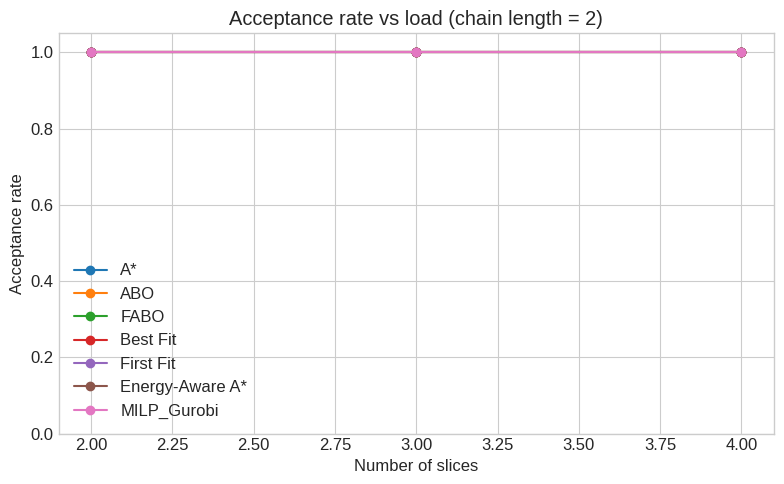

In [8]:
# ===========================================
# Acceptance rate vs number of slices
# for all chain lengths (num_vnfs_per_slice)
# ===========================================
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

# IMPORTANT: method names must match df_results["method"]
methods_order = [
    "A*",
    "ABO",
    "FABO",
    "Best Fit",
    "First Fit",
    "Energy-Aware A*",
    "MILP_Gurobi",          # <- this is the one used in the run notebook
]

print("[INFO] Methods present in df_results:", df_results["method"].unique())

# Directory to save figures – use latest_dir (where CSV came from)
fig_dir = os.path.join(latest_dir, "fig_acceptance")
os.makedirs(fig_dir, exist_ok=True)

# Loop over all tested chain lengths
for chain_len in sorted(df_results["num_vnfs_per_slice"].unique()):
    mask = df_results["num_vnfs_per_slice"] == chain_len

    fig, ax = plt.subplots()

    for method in methods_order:
        # Skip methods that are not present in df_results
        if method not in df_results["method"].unique():
            continue

        sub = df_results[mask & (df_results["method"] == method)]
        if sub.empty:
            continue

        # Average over seeds for each load level
        grouped = (
            sub.groupby("num_slices")["acceptance_rate"]
            .mean()
            .reset_index()
            .sort_values("num_slices")
        )

        ax.plot(
            grouped["num_slices"],
            grouped["acceptance_rate"],
            marker="o",
            label=method,
        )

    ax.set_xlabel("Number of slices")
    ax.set_ylabel("Acceptance rate")
    ax.set_title(f"Acceptance rate vs load (chain length = {chain_len})")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()

    # Save one figure per chain length
    acceptance_fig_path = os.path.join(
        fig_dir, f"acceptance_vs_load_vnfs{chain_len}.png"
    )
    plt.savefig(acceptance_fig_path, dpi=300)
    print(f"[INFO] Figure saved to: {acceptance_fig_path}")

    plt.show()


In [10]:
# ============================
# Load results and add columns
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Base directory where the experiment was saved
base_dir = "./results/2026-01-05_10-28-22"

# Build full path to the CSV file
results_path = os.path.join(base_dir, "scalability_results.csv")
print("[INFO] Loading:", results_path)

df_results = pd.read_csv(results_path)

print("[INFO] df_results shape:", df_results.shape)
print(df_results.head())

# --- Derived metrics ---
df_results["acceptance_rate"] = df_results["accepted"] / df_results["num_slices"]

df_results["energy_per_accepted_slice"] = df_results.apply(
    lambda row: row["total_energy"] / row["accepted"] if row["accepted"] > 0 else np.nan,
    axis=1,
)

df_results["latency_per_accepted_slice"] = df_results.apply(
    lambda row: row["total_latency"] / row["accepted"] if row["accepted"] > 0 else np.nan,
    axis=1,
)

print("\n[INFO] Methods:", df_results["method"].unique())
print("[INFO] num_vnfs_per_slice:", df_results["num_vnfs_per_slice"].unique())


[INFO] Loading: ./results/2026-01-05_10-28-22/scalability_results.csv
[INFO] df_results shape: (21, 11)
             timestamp  num_slices  num_vnfs_per_slice  total_vnfs  seed  \
0  2026-01-05 10:28:36           2                   2           4     1   
1  2026-01-05 10:28:36           2                   2           4     1   
2  2026-01-05 10:28:36           2                   2           4     1   
3  2026-01-05 10:28:36           2                   2           4     1   
4  2026-01-05 10:28:36           2                   2           4     1   

      method  accepted  total_energy  total_bandwidth  total_latency  \
0         A*         2        5.7225             80.0            2.0   
1        ABO         2        3.4550             80.0            4.0   
2       FABO         2        6.6825             80.0            4.0   
3   Best Fit         2        3.7225             80.0            2.0   
4  First Fit         2        3.6425             80.0            6.0   

   run

In [11]:
df_results["energy_per_accepted_slice"] = df_results.apply(
    lambda row: row["total_energy"] / row["accepted"] if row["accepted"] > 0 else np.nan,
    axis=1,
)


[INFO] Figure saved to: ./results/2026-01-05_10-28-22/fig_energy_per_slice/energy_per_accepted_slice.png


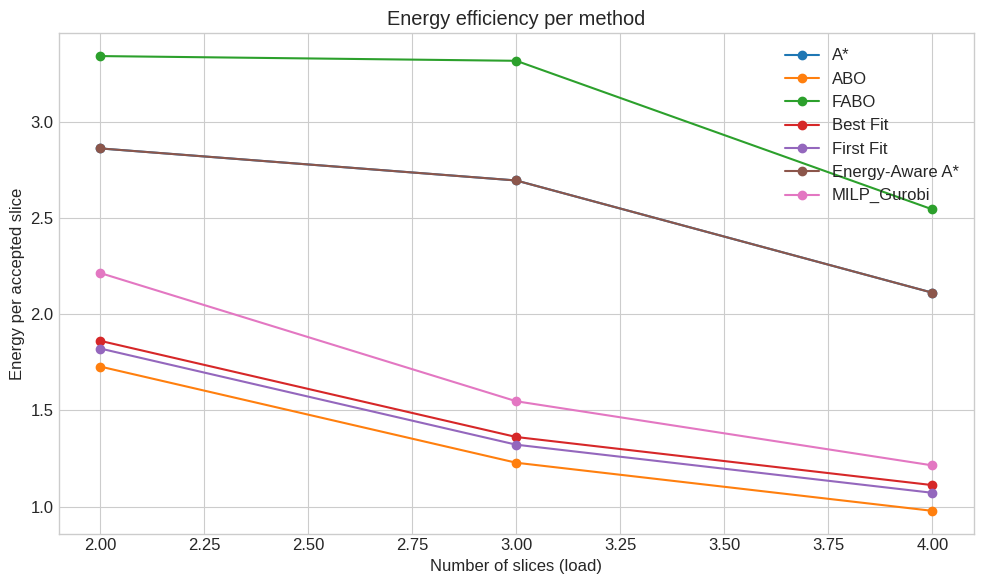

In [12]:
# ============================================
# Energy per accepted slice vs number of slices
# ============================================
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# IMPORTANT: match names inside df_results["method"]
methods_order = [
    "A*", "ABO", "FABO",
    "Best Fit", "First Fit",
    "Energy-Aware A*",
    "MILP_Gurobi",   # corrected name
]

fig_dir = os.path.join(latest_dir, "fig_energy_per_slice")
os.makedirs(fig_dir, exist_ok=True)

fig, ax = plt.subplots()

available_methods = df_results["method"].unique()

for method in methods_order:
    if method not in available_methods:
        continue

    sub = df_results[df_results["method"] == method].dropna(subset=["energy_per_accepted_slice"])
    if sub.empty:
        continue
    
    grouped = (
        sub.groupby("num_slices")["energy_per_accepted_slice"]
           .mean()
           .reset_index()
           .sort_values("num_slices")
    )

    ax.plot(
        grouped["num_slices"],
        grouped["energy_per_accepted_slice"],
        marker="o",
        label=method
    )

ax.set_xlabel("Number of slices (load)")
ax.set_ylabel("Energy per accepted slice")
ax.set_title("Energy efficiency per method")
ax.legend()
plt.tight_layout()

fig_path = os.path.join(fig_dir, "energy_per_accepted_slice.png")
plt.savefig(fig_path, dpi=300)
print(f"[INFO] Figure saved to: {fig_path}")

plt.show()


[INFO] Methods in df_results: ['A*' 'ABO' 'FABO' 'Best Fit' 'First Fit' 'Energy-Aware A*' 'MILP_Gurobi']
[INFO] Methods that will be plotted: ['A*', 'ABO', 'FABO', 'Best Fit', 'First Fit', 'Energy-Aware A*', 'MILP_Gurobi']
[INFO] Chain lengths found: [np.int64(2)]
[INFO] Figure saved to: ./results/2026-01-05_10-28-22/fig_energy_per_slice_by_chain/energy_per_slice_vs_load_vnfs2.png


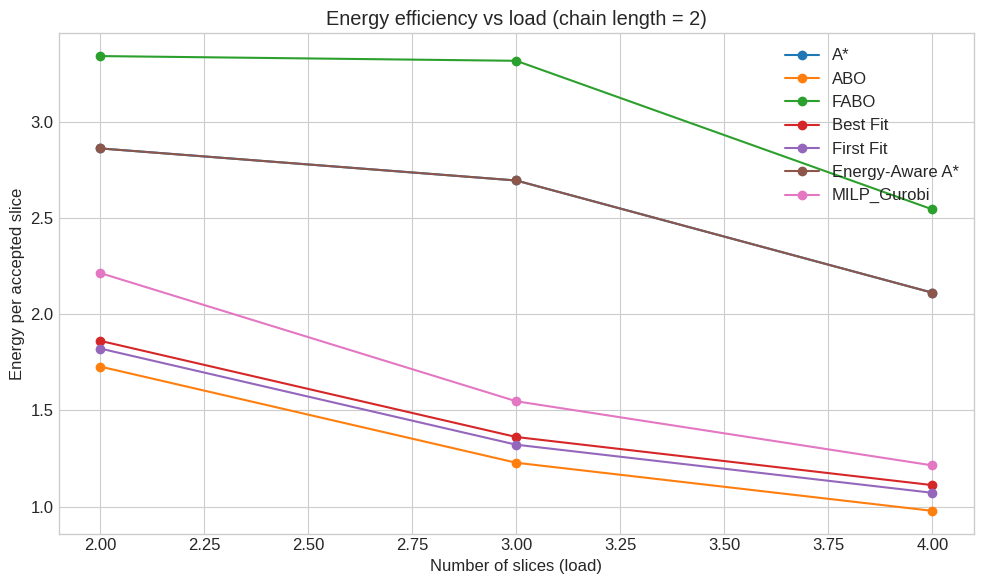

In [13]:
# ============================================
# Energy per accepted slice, split by chain length (2, 3, 4)
# ============================================
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Discover available methods from the data
available_methods = df_results["method"].unique()
print("[INFO] Methods in df_results:", available_methods)

# Base (heuristic) methods we would like to show if present
base_methods = [
    "A*", "ABO", "FABO",
    "Best Fit", "First Fit",
    "Energy-Aware A*",
]

# Add only those base methods that actually exist
methods_order = [m for m in base_methods if m in available_methods]

# Automatically include any MILP-like method (e.g., 'MILP (Gurobi)', 'MILP_Gurobi', etc.)
milp_methods = [m for m in available_methods if "MILP" in m]
methods_order += milp_methods

print("[INFO] Methods that will be plotted:", methods_order)

chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())
print("[INFO] Chain lengths found:", chain_lengths)

# Directory to save figures -> use latest_dir (where CSV was loaded)
fig_dir = os.path.join(latest_dir, "fig_energy_per_slice_by_chain")
os.makedirs(fig_dir, exist_ok=True)

for chain_len in chain_lengths:
    fig, ax = plt.subplots()

    # Filter by chain length
    mask = df_results["num_vnfs_per_slice"] == chain_len

    for method in methods_order:
        sub = df_results[mask & (df_results["method"] == method)]
        sub = sub.dropna(subset=["energy_per_accepted_slice"])
        if sub.empty:
            continue

        # Average energy per accepted slice over seeds for each load
        grouped = (
            sub.groupby("num_slices")["energy_per_accepted_slice"]
               .mean()
               .reset_index()
               .sort_values("num_slices")
        )

        ax.plot(
            grouped["num_slices"],
            grouped["energy_per_accepted_slice"],
            marker="o",
            label=method
        )

    ax.set_xlabel("Number of slices (load)")
    ax.set_ylabel("Energy per accepted slice")
    ax.set_title(f"Energy efficiency vs load (chain length = {chain_len})")
    ax.legend()
    plt.tight_layout()

    fig_path = os.path.join(fig_dir, f"energy_per_slice_vs_load_vnfs{chain_len}.png")
    plt.savefig(fig_path, dpi=300)
    print(f"[INFO] Figure saved to: {fig_path}")

    plt.show()


In [14]:
summary_var = (
    df_results
    .groupby(["method", "num_slices", "num_vnfs_per_slice"])
    .agg(
        mean_energy=("energy_per_accepted_slice", "mean"),
        std_energy=("energy_per_accepted_slice", "std"),
    )
    .reset_index()
)

summary_var[summary_var["method"] == "ABO"]


,method,num_slices,num_vnfs_per_slice,mean_energy,std_energy
3,ABO,2,2,1.7275,NaN
4,ABO,3,2,1.2275,NaN
5,ABO,4,2,0.9775,NaN


/tmp/ipykernel_289066/1842794245.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


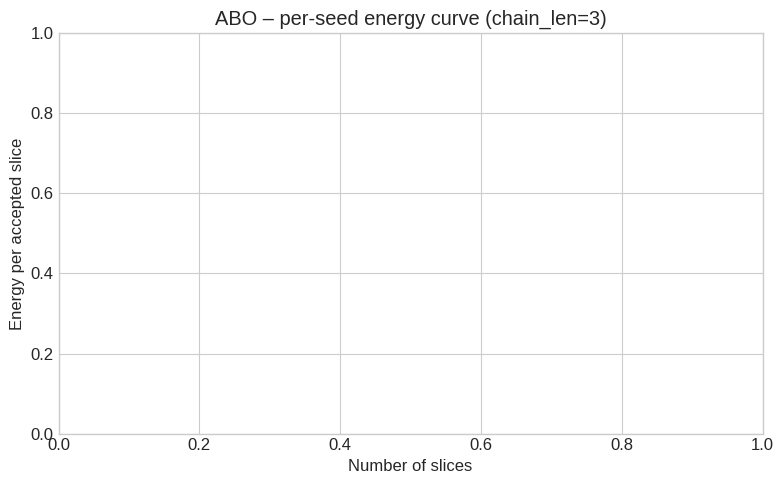

In [15]:
import matplotlib.pyplot as plt

chain_len = 3  # ou 2 / 4
mask = df_results["num_vnfs_per_slice"] == chain_len
abo = df_results[mask & (df_results["method"] == "ABO")]

plt.figure(figsize=(8,5))
for seed in sorted(abo["seed"].unique()):
    sub = abo[abo["seed"] == seed].dropna(subset=["energy_per_accepted_slice"])
    grouped = (
        sub.groupby("num_slices")["energy_per_accepted_slice"]
           .mean()
           .reset_index()
           .sort_values("num_slices")
    )
    plt.plot(grouped["num_slices"], grouped["energy_per_accepted_slice"], marker="o", label=f"seed={seed}")

plt.xlabel("Number of slices")
plt.ylabel("Energy per accepted slice")
plt.title(f"ABO – per-seed energy curve (chain_len={chain_len})")
plt.legend()
plt.tight_layout()
plt.show()


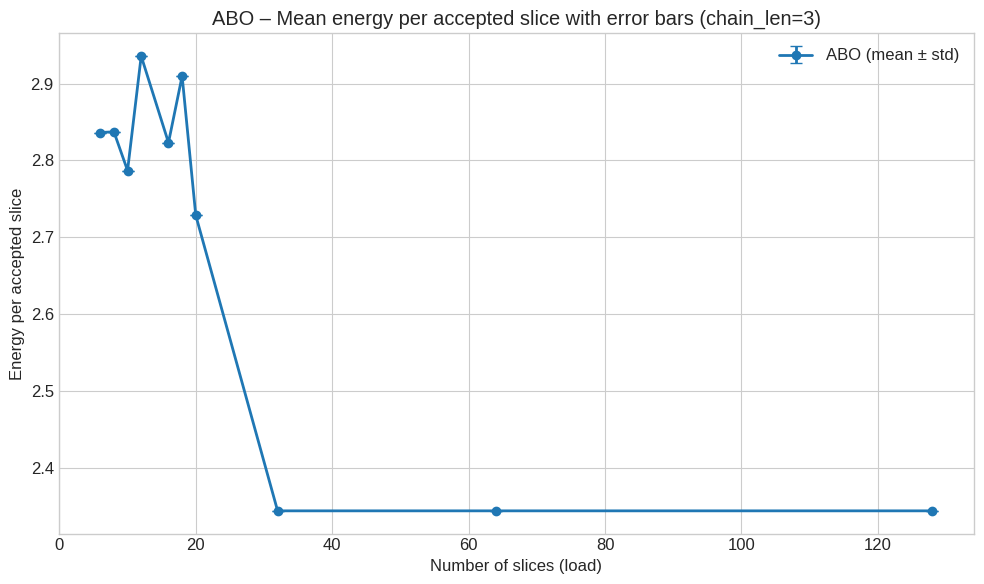

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

method = "ABO"
chain_len = 3

# Filtra o dataset
sub = df_results[
    (df_results["method"] == method) &
    (df_results["num_vnfs_per_slice"] == chain_len)
].dropna(subset=["energy_per_accepted_slice"])

if sub.empty:
    print("[ERROR] No data found for this configuration!")
else:
    # Agrupa média e desvio padrão por número de slices
    grouped = (
        sub.groupby("num_slices")["energy_per_accepted_slice"]
           .agg(["mean", "std"])
           .reset_index()
           .sort_values("num_slices")
    )

    x = grouped["num_slices"]
    y = grouped["mean"]
    yerr = grouped["std"]

    # Plot
    plt.errorbar(
        x, y, yerr=yerr,
        marker="o",
        capsize=4,
        linewidth=2,
        markersize=6,
        label=f"{method} (mean ± std)"
    )

    plt.xlabel("Number of slices (load)")
    plt.ylabel("Energy per accepted slice")
    plt.title(f"{method} – Mean energy per accepted slice with error bars (chain_len={chain_len})")
    plt.legend()
    plt.tight_layout()

    plt.show()


In [29]:
import random
import numpy as np

from heuristics.run_abo_full_batch import run_abo_full_batch
from utils.topology import topologie_finlande
from utils.generate_slices import generate_random_slices
from utils.metrics import count_accepted_slices

# --- Topology and capacities ---
G = topologie_finlande()
ENTRY = 6

node_capacity_base = {n: G.nodes[n]["cpu"] for n in G.nodes}
link_capacity_base = {(u, v): G[u][v]["bandwidth"] for u, v in G.edges}
link_capacity_base.update({(v, u): G[u][v]["bandwidth"] for u, v in G.edges})
link_latency = {(u, v): G[u][v]["latency"] for u, v in G.edges}
link_latency.update({(v, u): G[u][v]["latency"] for u, v in G.edges})

# --- VNF profiles (use os mesmos da simulação principal) ---
vnf_profiles = [
    {"cpu": 2, "throughput": 40, "latency": 120},
    {"cpu": 4, "throughput": 50, "latency": 180},
    {"cpu": 6, "throughput": 60, "latency": 200},
    {"cpu": 8, "throughput": 75, "latency": 250},
]

# --- Fix a slice pool once (so it is the same for all seeds) ---
BASE_SEED = 123
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)

num_slices_test = 32          # choose a load level to test
num_vnfs_per_slice_test = 3   # choose chain length

slices = generate_random_slices(
    G,
    vnf_profiles,
    num_slices=num_slices_test,
    num_vnfs_per_slice=num_vnfs_per_slice_test,
    entry=ENTRY,
)

print(f"[INFO] Generated {len(slices)} slices with {num_vnfs_per_slice_test} VNFs each.")

# --- Now test ABO with different RNG seeds ---
for seed in [10, 20, 30, 40, 50]:
    # If ABO uses randomness internally, this should affect it
    random.seed(seed)
    np.random.seed(seed)

    df_res, res_list = run_abo_full_batch(
        G,
        slices,
        node_capacity_base,
        link_latency,
        link_capacity_base,
    )

    accepted = count_accepted_slices(res_list, slices)
    print(f"seed={seed} -> accepted={accepted}")


[INFO] Generated 32 slices with 3 VNFs each.

[INFO][ABO] === Solving slice 1 (3 VNFs, 2 VLs) ===
[INFO][ABO] Found feasible solution after 44 states.
[SUMMARY][ABO] Slice 1 accepted. min_node_cpu=10, links_low_bw=0

[INFO][ABO] === Solving slice 2 (3 VNFs, 2 VLs) ===
[INFO][ABO] Found feasible solution after 41 states.
[SUMMARY][ABO] Slice 2 accepted. min_node_cpu=10, links_low_bw=0

[INFO][ABO] === Solving slice 3 (3 VNFs, 2 VLs) ===
[INFO][ABO] Found feasible solution after 36 states.
[SUMMARY][ABO] Slice 3 accepted. min_node_cpu=4, links_low_bw=0

[INFO][ABO] === Solving slice 4 (3 VNFs, 2 VLs) ===
[INFO][ABO] Found feasible solution after 35 states.
[SUMMARY][ABO] Slice 4 accepted. min_node_cpu=4, links_low_bw=0

[INFO][ABO] === Solving slice 5 (3 VNFs, 2 VLs) ===
[INFO][ABO] Found feasible solution after 43 states.
[SUMMARY][ABO] Slice 5 accepted. min_node_cpu=4, links_low_bw=0

[INFO][ABO] === Solving slice 6 (3 VNFs, 2 VLs) ===
[INFO][ABO] Found feasible solution after 40 state

[INFO] Smoothed figure saved to: ./results/2025-12-03_08-44-43/fig_energy_smoothed/energy_smoothed_vnfs2.png


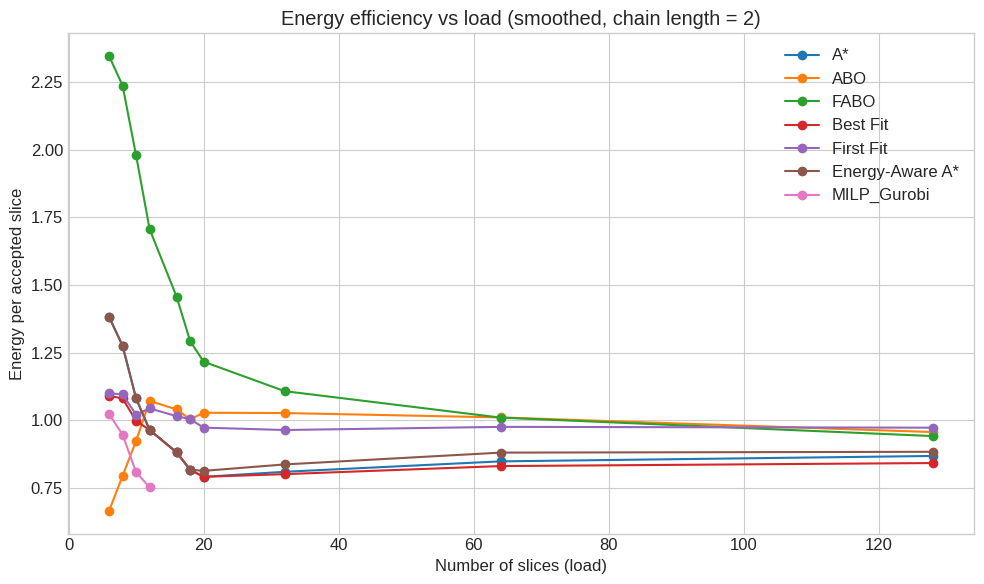

[INFO] Smoothed figure saved to: ./results/2025-12-03_08-44-43/fig_energy_smoothed/energy_smoothed_vnfs3.png


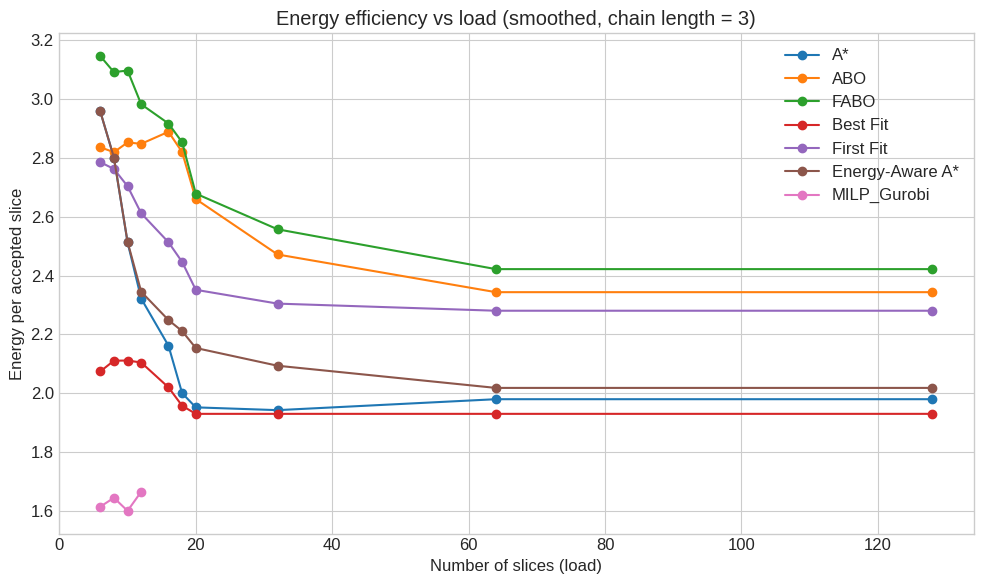

[INFO] Smoothed figure saved to: ./results/2025-12-03_08-44-43/fig_energy_smoothed/energy_smoothed_vnfs4.png


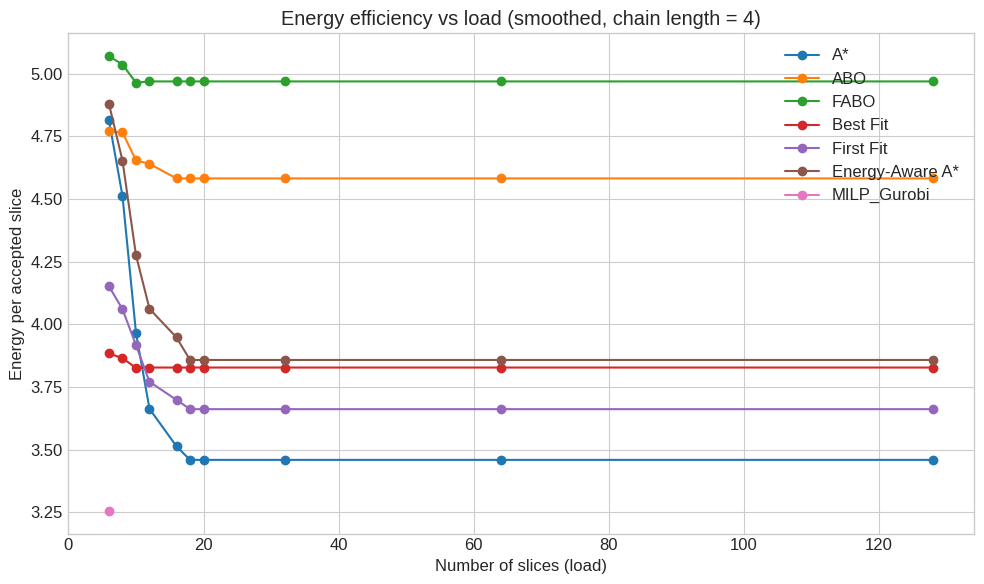

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

base_methods = [
    "A*", "ABO", "FABO",
    "Best Fit", "First Fit",
    "Energy-Aware A*",
]
available_methods = df_results["method"].unique()
methods_order = [m for m in base_methods if m in available_methods]
methods_order += [m for m in available_methods if "MILP" in m]

fig_dir = os.path.join(latest_dir, "fig_energy_smoothed")
os.makedirs(fig_dir, exist_ok=True)

def smooth_series(y, window=3):
    return y.rolling(window=window, center=True, min_periods=1).mean()

chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())

for chain_len in chain_lengths:
    fig, ax = plt.subplots()

    mask = df_results["num_vnfs_per_slice"] == chain_len

    for method in methods_order:
        sub = df_results[mask & (df_results["method"] == method)]
        sub = sub.dropna(subset=["energy_per_accepted_slice"])
        if sub.empty:
            continue

        grouped = (
            sub.groupby("num_slices")["energy_per_accepted_slice"]
               .mean()
               .reset_index()
               .sort_values("num_slices")
        )

        x = grouped["num_slices"]
        y = grouped["energy_per_accepted_slice"]
        y_smooth = smooth_series(y, window=3)

        ax.plot(x, y_smooth, marker="o", label=method)

    ax.set_xlabel("Number of slices (load)")
    ax.set_ylabel("Energy per accepted slice")
    ax.set_title(f"Energy efficiency vs load (smoothed, chain length = {chain_len})")
    ax.legend()
    plt.tight_layout()

    fig_path = os.path.join(fig_dir, f"energy_smoothed_vnfs{chain_len}.png")
    plt.savefig(fig_path, dpi=300)
    print(f"[INFO] Smoothed figure saved to: {fig_path}")

    plt.show()


In [5]:
import os
import pandas as pd
import numpy as np

# Coloque aqui o diretório correto da pasta do experimento
results_dir = "./results/2025-12-03_08-44-43"

csv_path = os.path.join(results_dir, "scalability_results.csv")

print("[INFO] Loading CSV:", csv_path)

df_results = pd.read_csv(csv_path)

print("[INFO] df_results shape:", df_results.shape)
print(df_results.head())

# Derived metrics
df_results["acceptance_rate"] = df_results["accepted"] / df_results["num_slices"]

df_results["energy_per_accepted_slice"] = df_results.apply(
    lambda row: row["total_energy"] / row["accepted"] if row["accepted"] > 0 else np.nan,
    axis=1,
)

df_results["latency_per_accepted_slice"] = df_results.apply(
    lambda row: row["total_latency"] / row["accepted"] if row["accepted"] > 0 else np.nan,
    axis=1,
)


[INFO] Loading CSV: ./results/2025-12-03_08-44-43/scalability_results.csv
[INFO] df_results shape: (990, 11)
             timestamp  num_slices  num_vnfs_per_slice  total_vnfs  seed  \
0  2025-12-03 08:45:03           6                   2          12     1   
1  2025-12-03 08:45:03           6                   2          12     1   
2  2025-12-03 08:45:03           6                   2          12     1   
3  2025-12-03 08:45:03           6                   2          12     1   
4  2025-12-03 08:45:03           6                   2          12     1   

      method  accepted  total_energy  total_bandwidth  total_latency  \
0         A*         6        9.1675            240.0            6.0   
1        ABO         6        4.3650            240.0           12.0   
2       FABO         6       15.0075            240.0           12.0   
3   Best Fit         6        7.1675            240.0            6.0   
4  First Fit         6        7.1675            240.0           18.0   

 

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_energy_vs_acceptance_smoothed/energy_vs_acceptance_smoothed_vnfs2.png


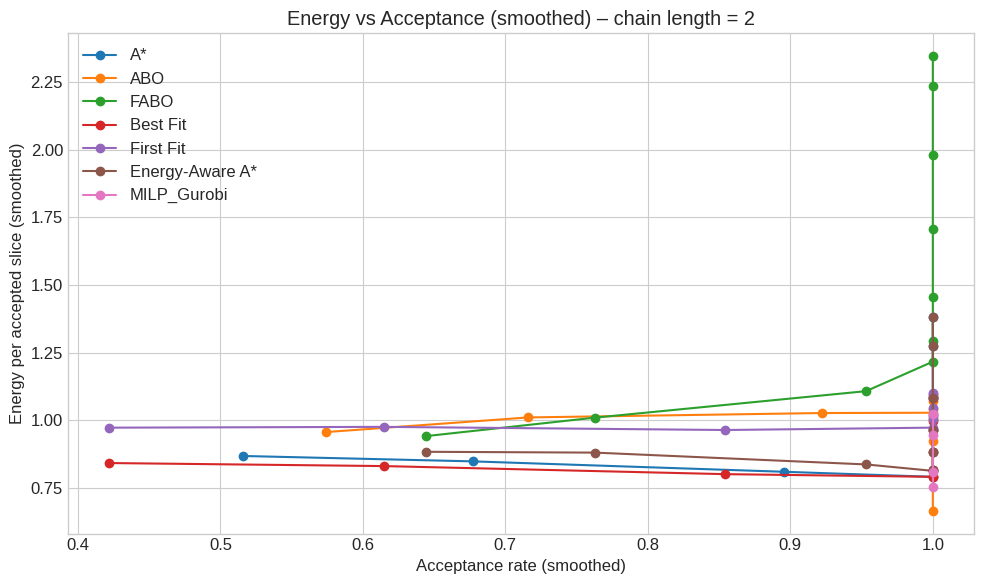

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_energy_vs_acceptance_smoothed/energy_vs_acceptance_smoothed_vnfs3.png


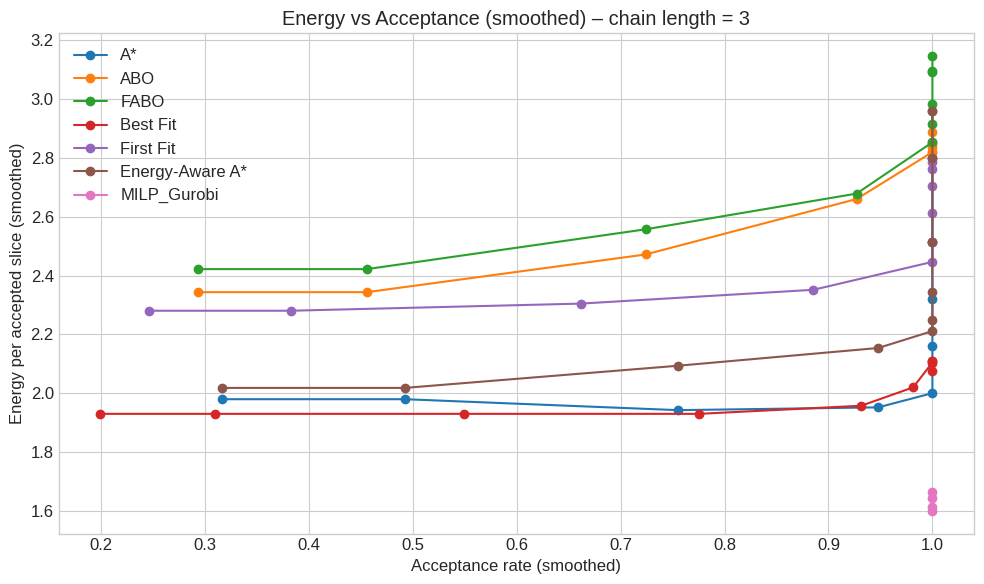

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_energy_vs_acceptance_smoothed/energy_vs_acceptance_smoothed_vnfs4.png


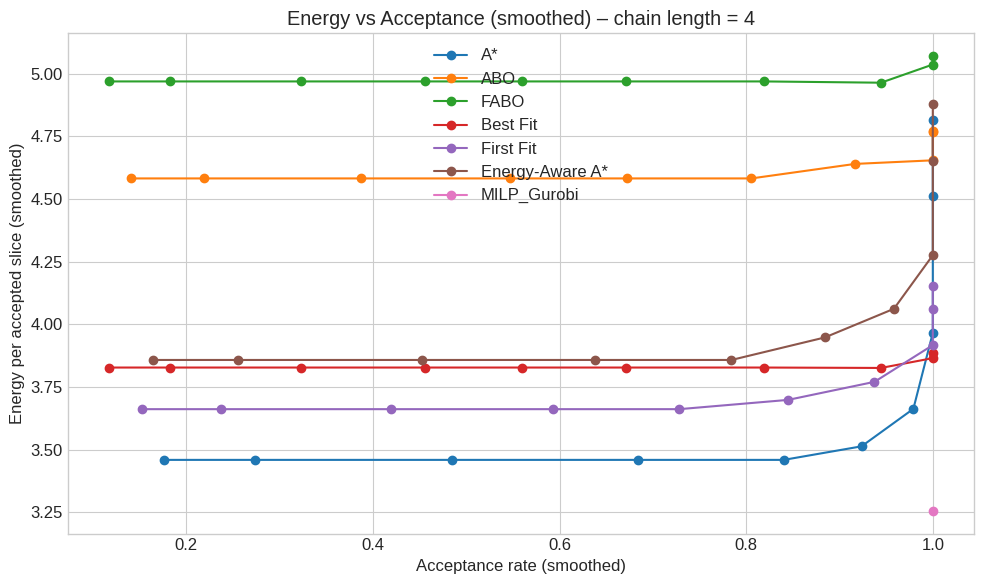

In [8]:
# ============================================================
# Energy per accepted slice vs Acceptance rate (smoothed)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ---- Diretório dos resultados já prontos ----
results_dir = "./results/2025-12-03_08-44-43"

# ---- Garante colunas derivadas ----
if "acceptance_rate" not in df_results.columns:
    df_results["acceptance_rate"] = df_results["accepted"] / df_results["num_slices"]

if "energy_per_accepted_slice" not in df_results.columns:
    df_results["energy_per_accepted_slice"] = df_results.apply(
        lambda row: row["total_energy"] / row["accepted"] 
        if row["accepted"] > 0 else np.nan,
        axis=1,
    )

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

base_methods = [
    "A*", "ABO", "FABO",
    "Best Fit", "First Fit",
    "Energy-Aware A*",
]
available_methods = df_results["method"].unique()

methods_order = [m for m in base_methods if m in available_methods]
methods_order += [m for m in available_methods if "MILP" in m]

# Onde salvar
fig_dir = os.path.join(results_dir, "fig_energy_vs_acceptance_smoothed")
os.makedirs(fig_dir, exist_ok=True)

# Suavização
def smooth_series(y, window=3):
    return y.rolling(window=window, center=True, min_periods=1).mean()

chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())

for chain_len in chain_lengths:
    fig, ax = plt.subplots()

    mask = df_results["num_vnfs_per_slice"] == chain_len

    for method in methods_order:
        sub = df_results[mask & (df_results["method"] == method)]
        sub = sub.dropna(subset=["energy_per_accepted_slice"])

        if sub.empty:
            continue

        # Média por número de slices (média sobre seeds)
        grouped = (
            sub.groupby("num_slices")
               .agg({
                   "acceptance_rate": "mean",
                   "energy_per_accepted_slice": "mean",
               })
               .reset_index()
               .sort_values("num_slices")
        )

        # Suavizar os dois eixos
        x = grouped["acceptance_rate"]
        y = grouped["energy_per_accepted_slice"]

        x_smooth = smooth_series(x, window=3)
        y_smooth = smooth_series(y, window=3)

        # Plot Energia vs Aceitação
        ax.plot(x_smooth, y_smooth, marker="o", label=method)

    ax.set_xlabel("Acceptance rate (smoothed)")
    ax.set_ylabel("Energy per accepted slice (smoothed)")
    ax.set_title(f"Energy vs Acceptance (smoothed) – chain length = {chain_len}")
    ax.legend()
    plt.tight_layout()

    fig_path = os.path.join(fig_dir, f"energy_vs_acceptance_smoothed_vnfs{chain_len}.png")
    plt.savefig(fig_path, dpi=300)
    print(f"[INFO] Saved: {fig_path}")

    plt.show()


[INFO] Loaded: ./results/2025-12-03_08-44-43/scalability_results.csv
[INFO] Saved: ./results/2025-12-03_08-44-43/fig_energy_vs_acceptance_smoothed/energy_vs_acceptance_smoothed_vnfs2.png


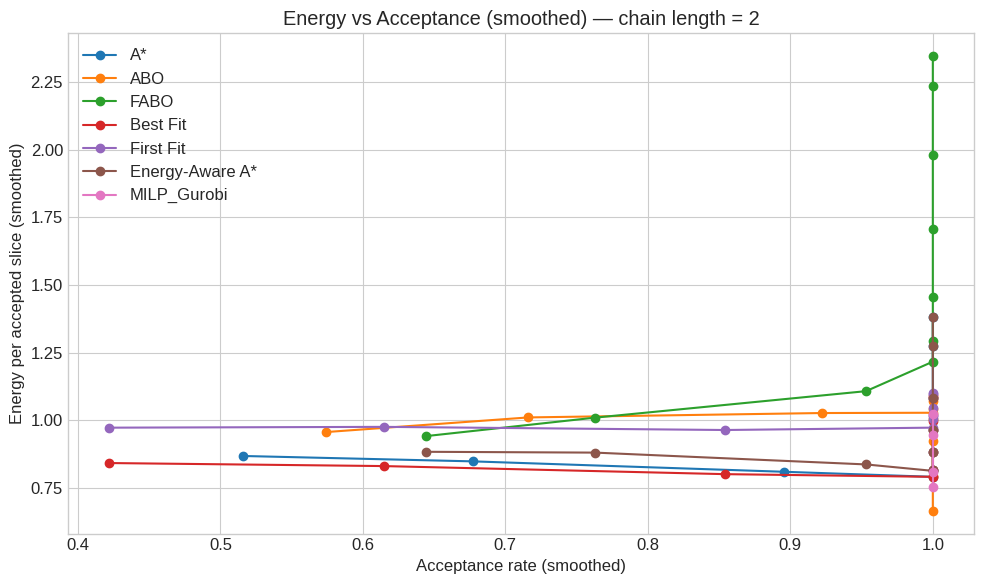

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_energy_vs_acceptance_smoothed/energy_vs_acceptance_smoothed_vnfs3.png


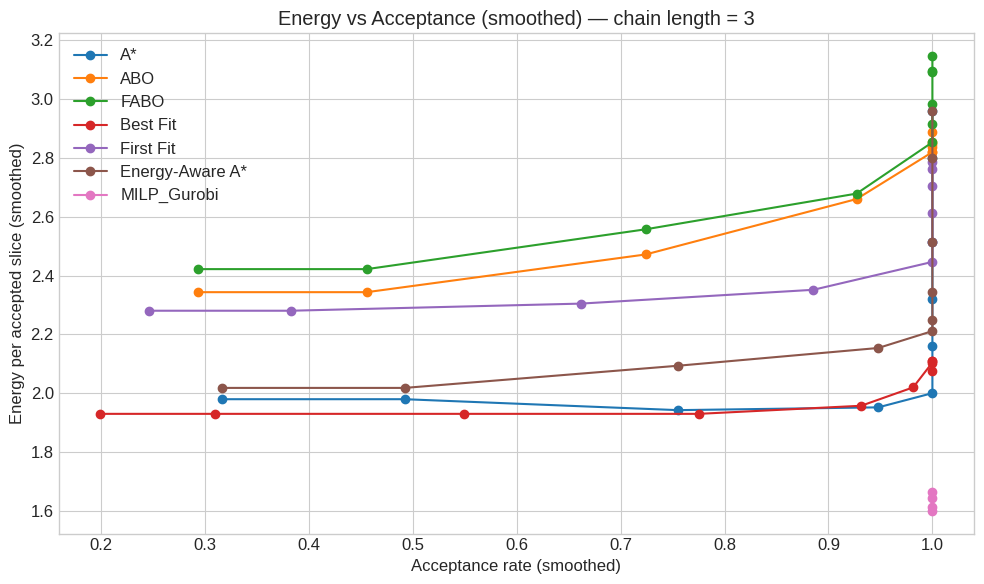

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_energy_vs_acceptance_smoothed/energy_vs_acceptance_smoothed_vnfs4.png


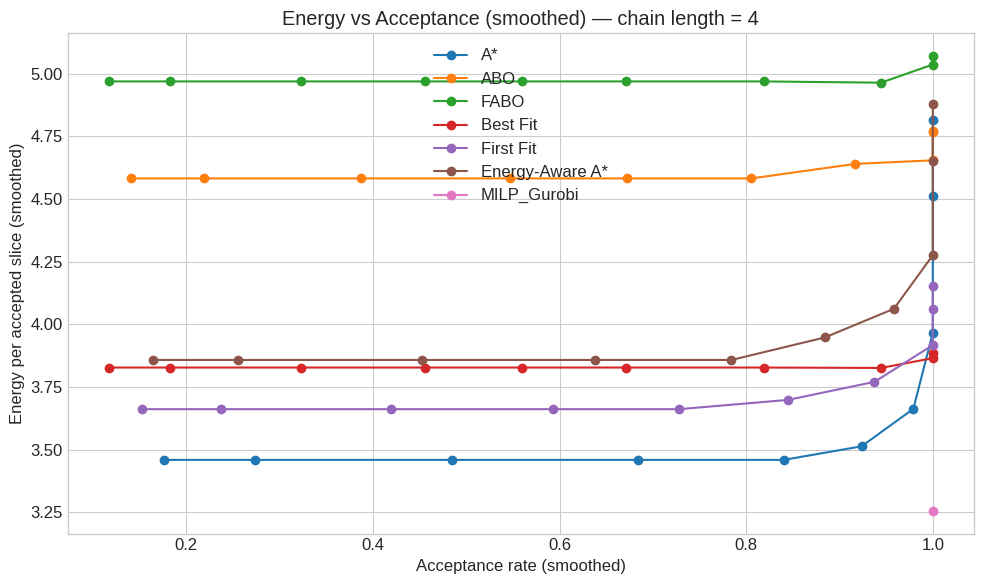

In [9]:
# ============================================================
# Energy per accepted slice vs Acceptance rate (smoothed)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ------------------------------------------------------------
# Load your results manually
# ------------------------------------------------------------
results_dir = "./results/2025-12-03_08-44-43"
csv_path = os.path.join(results_dir, "scalability_results.csv")

df_results = pd.read_csv(csv_path)
print("[INFO] Loaded:", csv_path)

# ------------------------------------------------------------
# Derived metrics (if not already included)
# ------------------------------------------------------------
if "acceptance_rate" not in df_results.columns:
    df_results["acceptance_rate"] = df_results["accepted"] / df_results["num_slices"]

if "energy_per_accepted_slice" not in df_results.columns:
    df_results["energy_per_accepted_slice"] = df_results.apply(
        lambda row: row["total_energy"] / row["accepted"] 
        if row["accepted"] > 0 else np.nan,
        axis=1,
    )

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Preferred order
base_methods = [
    "A*", "ABO", "FABO",
    "Best Fit", "First Fit",
    "Energy-Aware A*",
]
available_methods = df_results["method"].unique()
methods_order = [m for m in base_methods if m in available_methods]
methods_order += [m for m in available_methods if "MILP" in m]

# Output directory
fig_dir = os.path.join(results_dir, "fig_energy_vs_acceptance_smoothed")
os.makedirs(fig_dir, exist_ok=True)

# ------------------------------------------------------------
# Moving average smoothing
# ------------------------------------------------------------
def smooth_series(y, window=3):
    return y.rolling(window=window, center=True, min_periods=1).mean()

chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())

# ------------------------------------------------------------
# One plot per chain length
# ------------------------------------------------------------
for chain_len in chain_lengths:
    fig, ax = plt.subplots()

    mask = df_results["num_vnfs_per_slice"] == chain_len

    for method in methods_order:
        sub = df_results[mask & (df_results["method"] == method)]
        sub = sub.dropna(subset=["energy_per_accepted_slice"])

        if sub.empty:
            continue

        # Average across seeds
        grouped = (
            sub.groupby("num_slices")
               .agg({
                   "acceptance_rate": "mean",
                   "energy_per_accepted_slice": "mean"
               })
               .reset_index()
               .sort_values("num_slices")
        )

        # Smooth both axes
        x = grouped["acceptance_rate"]
        y = grouped["energy_per_accepted_slice"]

        x_smooth = smooth_series(x, window=3)
        y_smooth = smooth_series(y, window=3)

        # Plot Energy vs Acceptance
        ax.plot(x_smooth, y_smooth, marker="o", label=method)

    ax.set_xlabel("Acceptance rate (smoothed)")
    ax.set_ylabel("Energy per accepted slice (smoothed)")
    ax.set_title(f"Energy vs Acceptance (smoothed) — chain length = {chain_len}")
    ax.legend()
    plt.tight_layout()

    # Save
    fig_path = os.path.join(fig_dir, f"energy_vs_acceptance_smoothed_vnfs{chain_len}.png")
    plt.savefig(fig_path, dpi=300)
    print(f"[INFO] Saved: {fig_path}")

    plt.show()


[INFO] Loaded: ./results/2025-12-03_08-44-43/scalability_results.csv


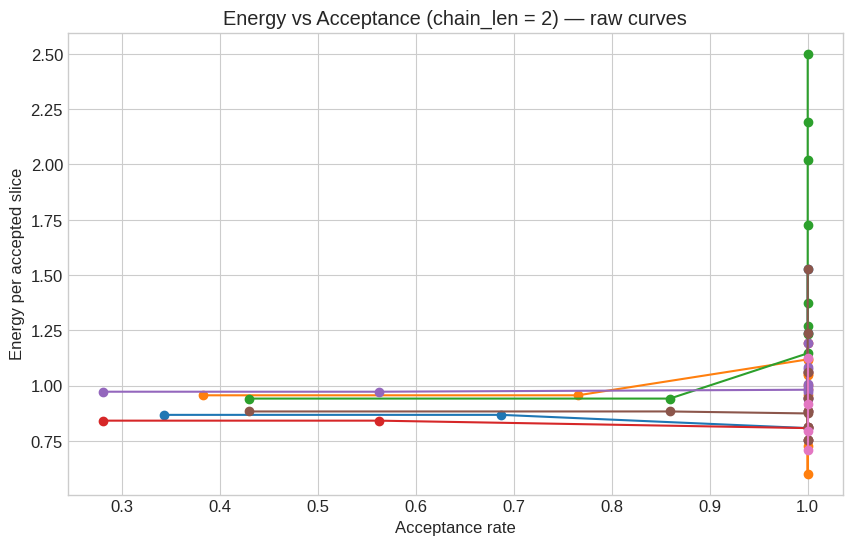

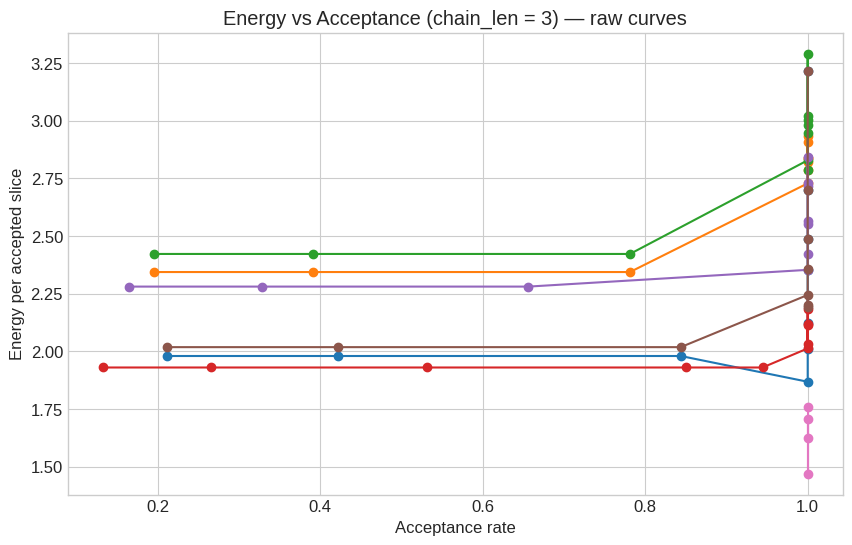

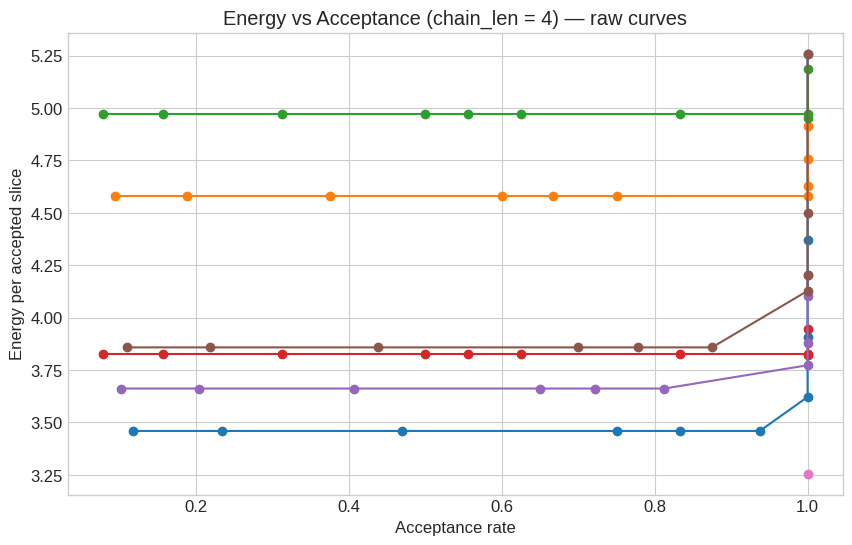

In [10]:
# ============================================================
# Energy per accepted slice vs Acceptance rate (NO smoothing)
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ---- Load your CSV manually ----
results_dir = "./results/2025-12-03_08-44-43"
csv_path = os.path.join(results_dir, "scalability_results.csv")

df_results = pd.read_csv(csv_path)
print("[INFO] Loaded:", csv_path)

# ---- Derived metrics ----
if "acceptance_rate" not in df_results:
    df_results["acceptance_rate"] = df_results["accepted"] / df_results["num_slices"]

if "energy_per_accepted_slice" not in df_results:
    df_results["energy_per_accepted_slice"] = df_results.apply(
        lambda row: row["total_energy"] / row["accepted"]
        if row["accepted"] > 0 else np.nan,
        axis=1
    )

# ---- Plot settings ----
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

base_methods = [
    "A*", "ABO", "FABO",
    "Best Fit", "First Fit",
    "Energy-Aware A*"
]

available_methods = df_results["method"].unique()
methods_order = [m for m in base_methods if m in available_methods]
methods_order += [m for m in available_methods if "MILP" in m]

# ---- Output directory ----
fig_dir = os.path.join(results_dir, "fig_energy_vs_acceptance_raw")
os.makedirs(fig_dir, exist_ok=True)

chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())

# ---- Main plotting ----
for chain_len in chain_lengths:

    fig, ax = plt.subplots()

    mask = df_results["num_vnfs_per_slice"] == chain_len

    for method in methods_order:
        sub = df_results[mask & (df_results["method"] == method)]
        sub = sub.dropna(subset=["energy_per_accepted_slice"])

        if sub.empty:
            continue

        # Aggregate per load (mean over seeds)
        grouped = (
            sub.groupby("num_slices")
               .agg({
                   "acceptance_rate": "mean",
                   "energy_per_accepted_slice": "mean"
               })
               .reset_index()
               .sort_values("num_slices")
        )

        x = grouped["acceptance_rate"]
        y = grouped["energy_per_accepted_slice"]

        ax.plot(x, y, marker="o", label=method)

    ax.set_xlabel("Acceptance rate")
    ax.set_ylabel("Energy per accepted slice")
    ax.set_title(f"Energy vs Acceptance (chain_len = {chain_len}) — raw curves")


[INFO] Loaded: ./results/2025-12-03_08-44-43/scalability_results.csv
[INFO] Saved: ./results/2025-12-03_08-44-43/fig_pareto/pareto_energy_acceptance_vnfs2.png


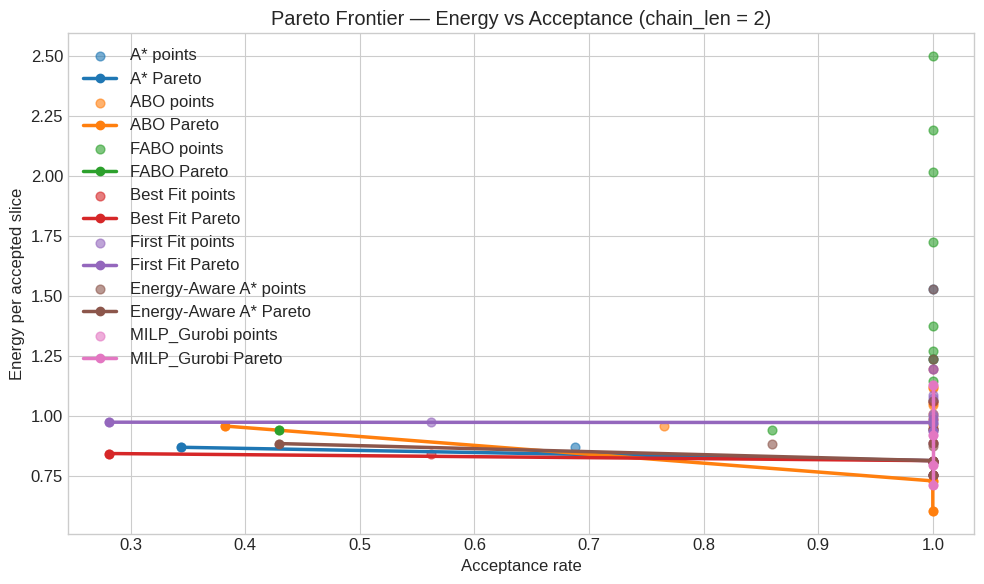

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_pareto/pareto_energy_acceptance_vnfs3.png


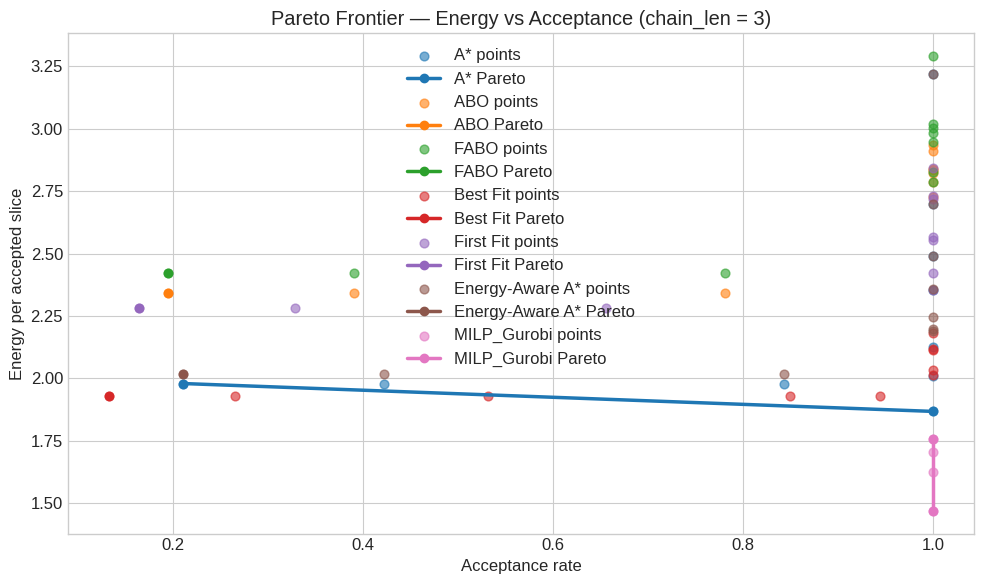

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_pareto/pareto_energy_acceptance_vnfs4.png


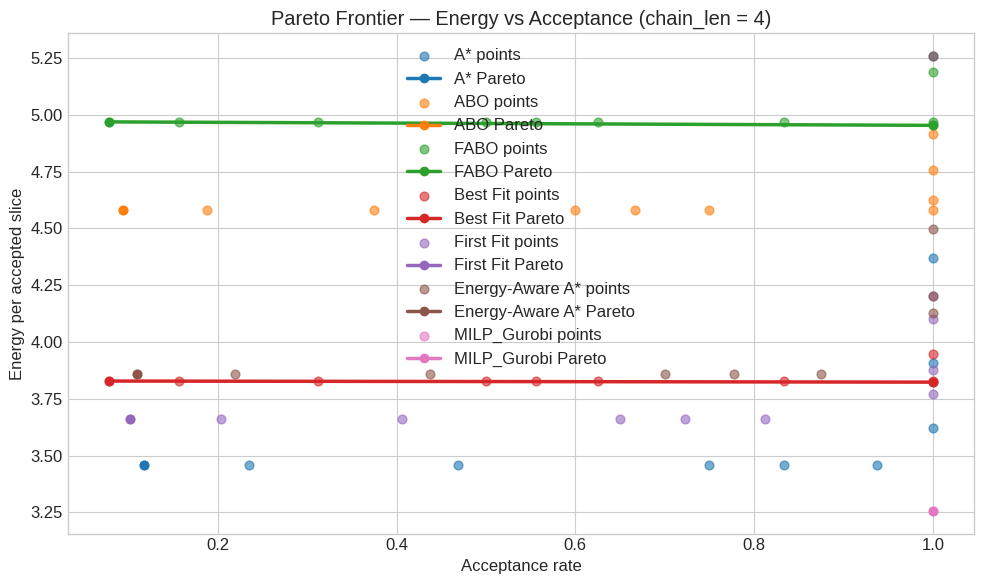

In [11]:
# ============================================================
# Pareto Frontier: Energy per accepted slice vs Acceptance rate
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


# ---- Load CSV manually ----
results_dir = "./results/2025-12-03_08-44-43"
csv_path = os.path.join(results_dir, "scalability_results.csv")

df_results = pd.read_csv(csv_path)
print("[INFO] Loaded:", csv_path)


# ---- Derived metrics ----
df_results["acceptance_rate"] = df_results["accepted"] / df_results["num_slices"]

df_results["energy_per_accepted_slice"] = df_results.apply(
    lambda row: row["total_energy"] / row["accepted"]
    if row["accepted"] > 0 else np.nan,
    axis=1,
)

# Remover cenários sem energia válida
df_results = df_results.dropna(subset=["energy_per_accepted_slice"])


# ---- Methods order ----
base_methods = [
    "A*", "ABO", "FABO",
    "Best Fit", "First Fit",
    "Energy-Aware A*"
]

available_methods = df_results["method"].unique()
methods_order = [m for m in base_methods if m in available_methods]
methods_order += [m for m in available_methods if "MILP" in m]


# ---- Pareto helper: extract non-dominated points ----
def pareto_frontier(df):
    df_sorted = df.sort_values("acceptance_rate")
    frontier = []
    best_energy = float("inf")

    for _, row in df_sorted.iterrows():
        if row["energy_per_accepted_slice"] < best_energy:
            frontier.append(row)
            best_energy = row["energy_per_accepted_slice"]

    return pd.DataFrame(frontier)


# ---- Output directory ----
fig_dir = os.path.join(results_dir, "fig_pareto")
os.makedirs(fig_dir, exist_ok=True)


# ---- Plot Pareto Frontier per chain_length ----
chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())

for chain_len in chain_lengths:

    fig, ax = plt.subplots(figsize=(10, 6))

    mask = df_results["num_vnfs_per_slice"] == chain_len

    for method in methods_order:
        sub = df_results[mask & (df_results["method"] == method)]

        if sub.empty:
            continue

        # Average across seeds for each load level
        grouped = (
            sub.groupby("num_slices")
               .agg({
                   "acceptance_rate": "mean",
                   "energy_per_accepted_slice": "mean"
               })
               .reset_index()
        )

        # scatter of all points
        ax.scatter(
            grouped["acceptance_rate"],
            grouped["energy_per_accepted_slice"],
            label=f"{method} points",
            s=40,
            alpha=0.6
        )

        # Compute Pareto frontier
        pf = pareto_frontier(grouped)

        ax.plot(
            pf["acceptance_rate"],
            pf["energy_per_accepted_slice"],
            linewidth=2.5,
            marker="o",
            label=f"{method} Pareto",
        )

    ax.set_xlabel("Acceptance rate")
    ax.set_ylabel("Energy per accepted slice")
    ax.set_title(f"Pareto Frontier — Energy vs Acceptance (chain_len = {chain_len})")
    ax.legend()
    plt.tight_layout()

    fig_path = os.path.join(fig_dir, f"pareto_energy_acceptance_vnfs{chain_len}.png")
    plt.savefig(fig_path, dpi=300)
    print("[INFO] Saved:", fig_path)

    plt.show()


[INFO] Saved: ./results/2025-12-03_08-44-43/fig_smoothed_per_seed/ABO_smoothed_chainlen2.png


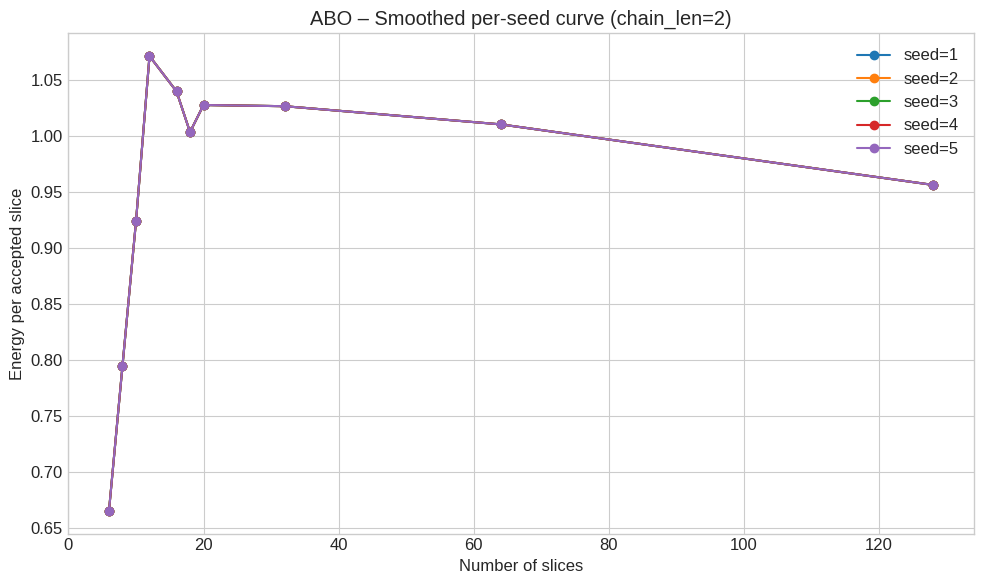

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_smoothed_per_seed/ABO_smoothed_chainlen3.png


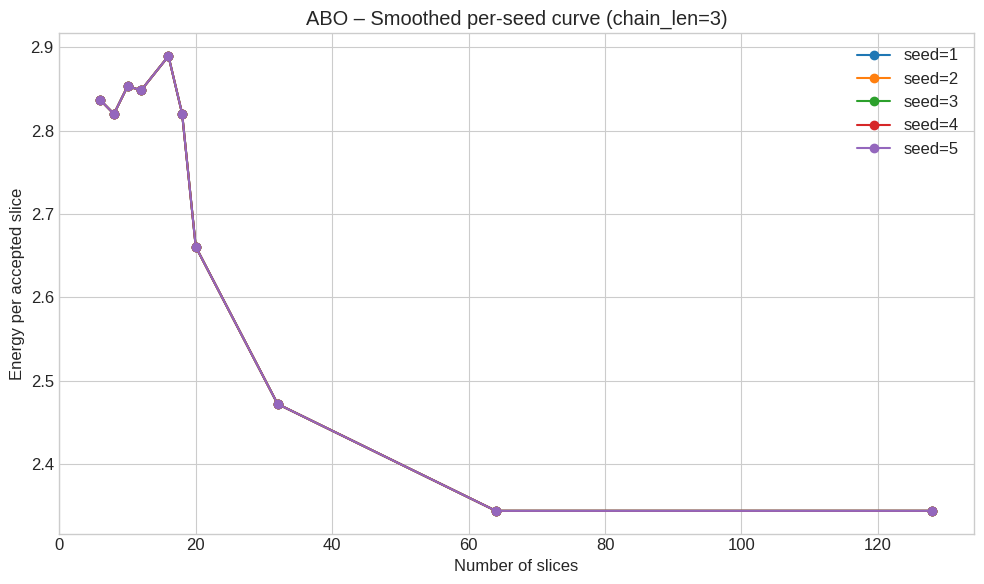

[INFO] Saved: ./results/2025-12-03_08-44-43/fig_smoothed_per_seed/ABO_smoothed_chainlen4.png


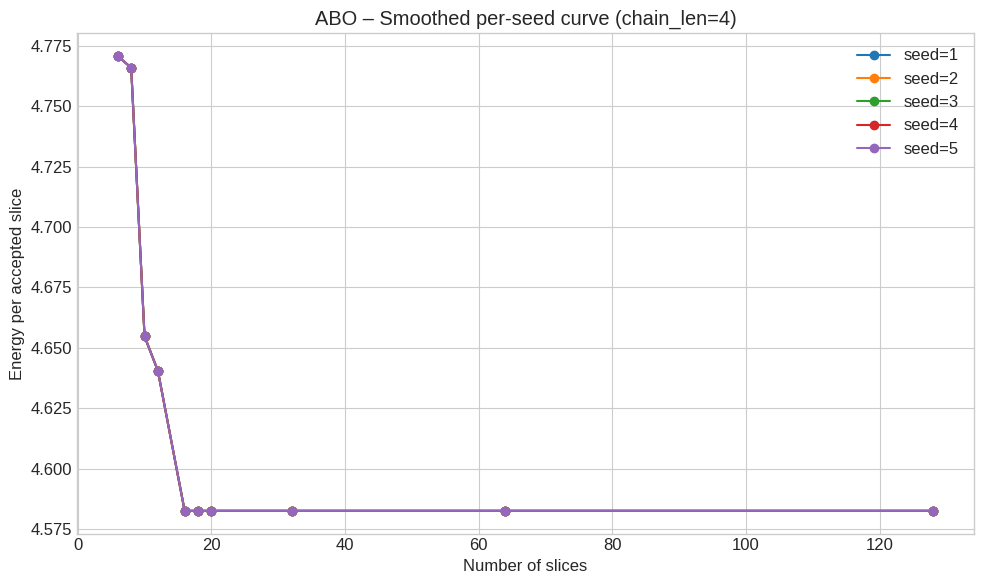

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Método desejado (troque aqui)
method_name = "ABO"      # ou "FABO", "A*", etc.

# Pasta de saída
fig_dir = os.path.join(latest_dir, "fig_smoothed_per_seed")
os.makedirs(fig_dir, exist_ok=True)

def smooth(y, window=3):
    """Média móvel centralizada (remove serrilhado)."""
    return y.rolling(window=window, center=True, min_periods=1).mean()

# Loop sobre chain lengths
chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())

for chain_len in chain_lengths:

    fig, ax = plt.subplots()

    # Filtrar por chain length e método
    mask = (
        (df_results["num_vnfs_per_slice"] == chain_len) &
        (df_results["method"] == method_name)
    )
    df_sub = df_results[mask].dropna(subset=["energy_per_accepted_slice"])

    if df_sub.empty:
        print(f"[WARN] No data for method={method_name}, chain_len={chain_len}")
        continue

    # Criar curvas por seed
    seeds = sorted(df_sub["seed"].unique())

    for seed in seeds:
        df_seed = (
            df_sub[df_sub["seed"] == seed]
            .groupby("num_slices")["energy_per_accepted_slice"]
            .mean()
            .reset_index()
            .sort_values("num_slices")
        )

        x = df_seed["num_slices"]
        y = df_seed["energy_per_accepted_slice"]
        y_smooth = smooth(y, window=3)

        ax.plot(x, y_smooth, marker="o", label=f"seed={seed}")

    ax.set_xlabel("Number of slices")
    ax.set_ylabel("Energy per accepted slice")
    ax.set_title(f"{method_name} – Smoothed per-seed curve (chain_len={chain_len})")
    ax.legend()
    plt.tight_layout()

    # Save
    fig_path = os.path.join(fig_dir, f"{method_name}_smoothed_chainlen{chain_len}.png")
    plt.savefig(fig_path, dpi=300)
    print(f"[INFO] Saved: {fig_path}")

    plt.show()


In [ ]:
from heuristics.run_abo_full_batch import run_abo_full_batch
from utils.topology import topologie_finlande
from utils.generate_slices import generate_random_slices

G = topologie_finlande()
slices = generate_random_slices()
for seed in [10,20,30,40,50]:
    test = run_abo_full_batch(G, slices, node_capacity_base, link_latency, link_capacity_base)
    print(seed, count_accepted_slices(test[1], slices))


NameError: name 'slices' is not defined

[INFO] FABO – chain lengths found in df_results: [np.int64(2), np.int64(3), np.int64(4)]
[INFO] Figure saved to: ./results/2025-12-03_08-44-43/fig_energy_per_seed_FABO/fabo_per_seed_chainlen2.png


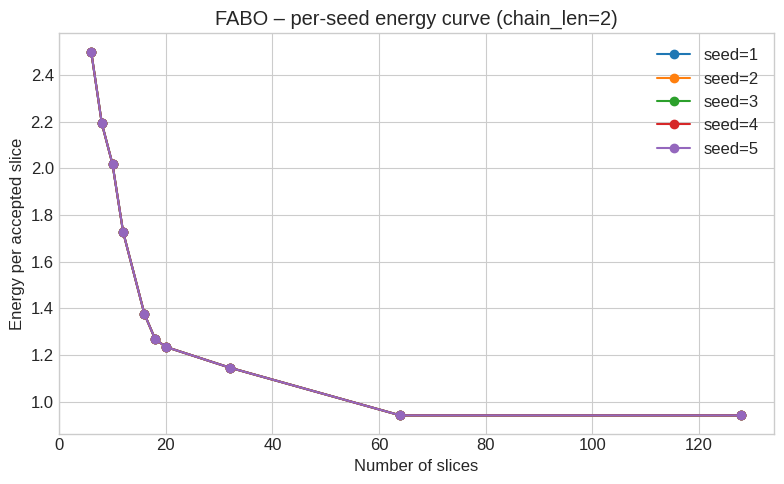

[INFO] Figure saved to: ./results/2025-12-03_08-44-43/fig_energy_per_seed_FABO/fabo_per_seed_chainlen3.png


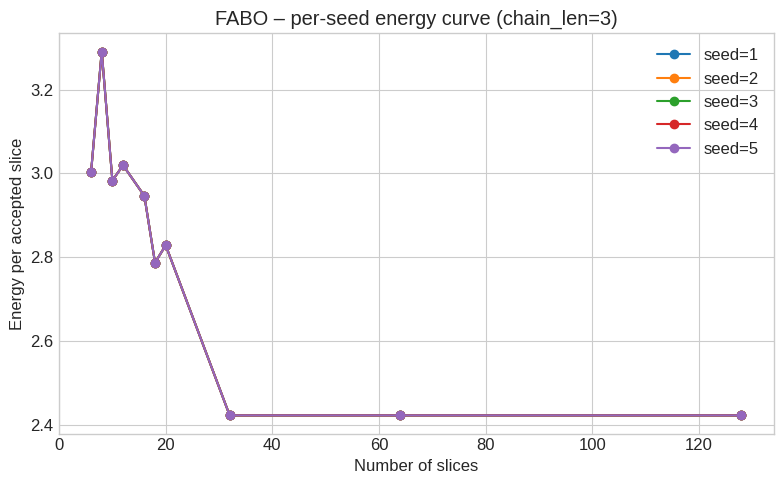

[INFO] Figure saved to: ./results/2025-12-03_08-44-43/fig_energy_per_seed_FABO/fabo_per_seed_chainlen4.png


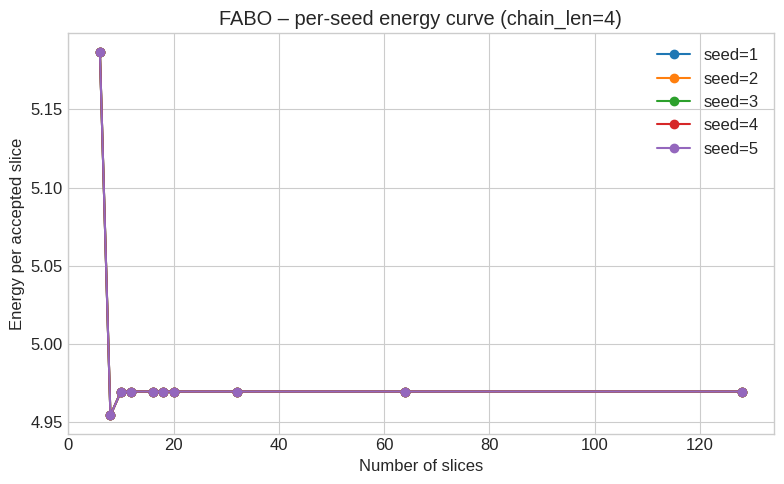

In [17]:
# ============================================
# FABO – per-seed energy curves for each chain length
# ============================================

import os
import matplotlib.pyplot as plt

method = "FABO"  # fixed method name
chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())

print(f"[INFO] FABO – chain lengths found in df_results: {chain_lengths}")

# Directory to save figures
fig_dir = os.path.join(latest_dir, "fig_energy_per_seed_FABO")
os.makedirs(fig_dir, exist_ok=True)

for chain_len in chain_lengths:
    # Filter rows for this method and chain length
    mask = (
        (df_results["method"] == method) &
        (df_results["num_vnfs_per_slice"] == chain_len)
    )
    sub = df_results[mask].dropna(subset=["energy_per_accepted_slice"])

    if sub.empty:
        print(f"[WARN] No FABO data for chain_len={chain_len}")
        continue

    plt.figure(figsize=(8, 5))

    # Plot one curve per seed
    for seed in sorted(sub["seed"].unique()):
        ssub = sub[sub["seed"] == seed]
        grouped = (
            ssub.groupby("num_slices")["energy_per_accepted_slice"]
                .mean()
                .reset_index()
                .sort_values("num_slices")
        )

        plt.plot(
            grouped["num_slices"],
            grouped["energy_per_accepted_slice"],
            marker="o",
            label=f"seed={seed}"
        )

    plt.xlabel("Number of slices")
    plt.ylabel("Energy per accepted slice")
    plt.title(f"FABO – per-seed energy curve (chain_len={chain_len})")
    plt.legend()
    plt.tight_layout()

    fig_path = os.path.join(fig_dir, f"fabo_per_seed_chainlen{chain_len}.png")
    plt.savefig(fig_path, dpi=300)
    print(f"[INFO] Figure saved to: {fig_path}")

    plt.show()


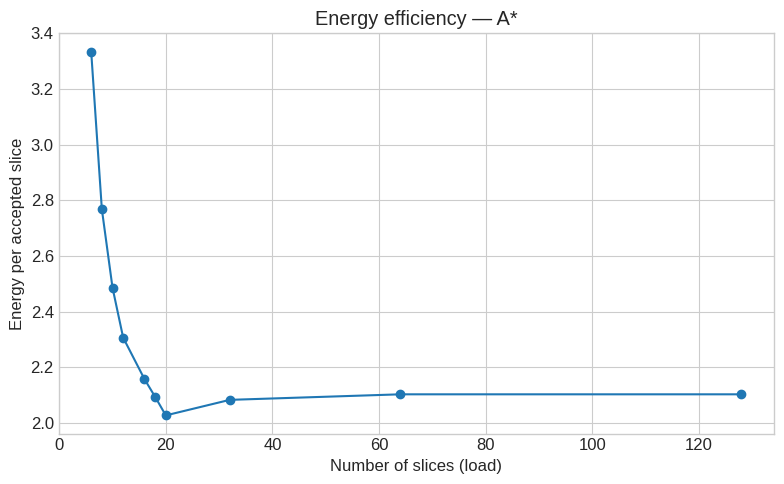

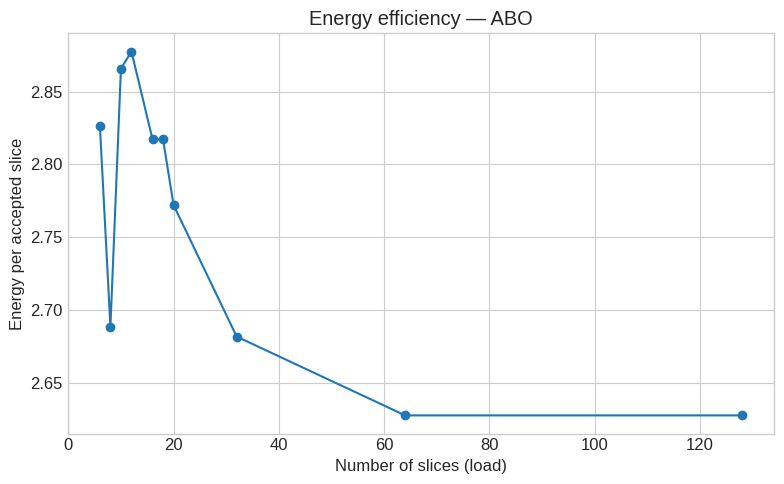

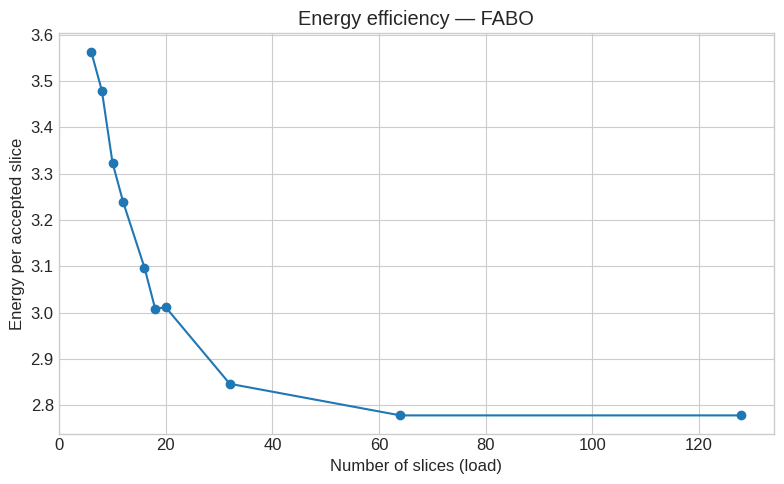

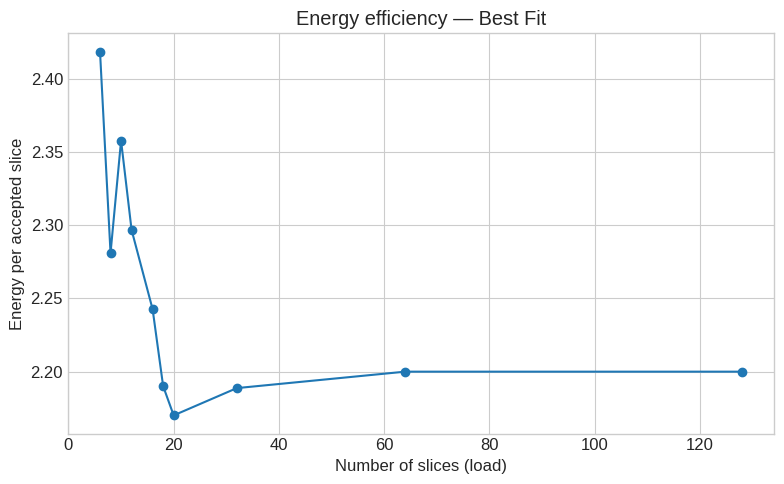

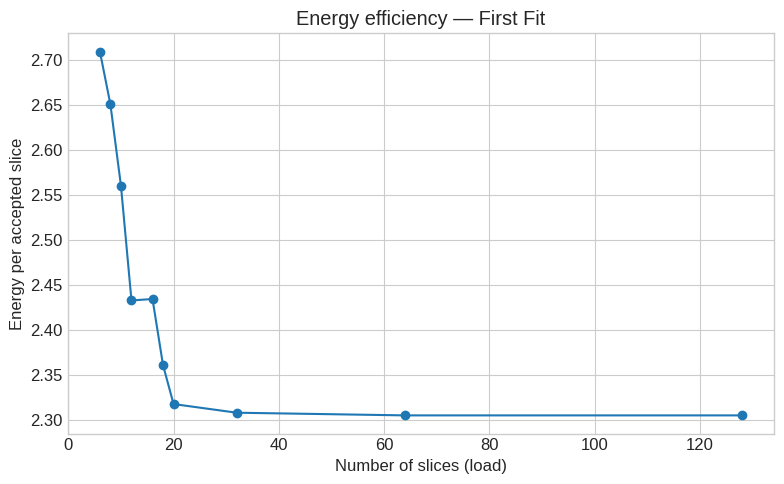

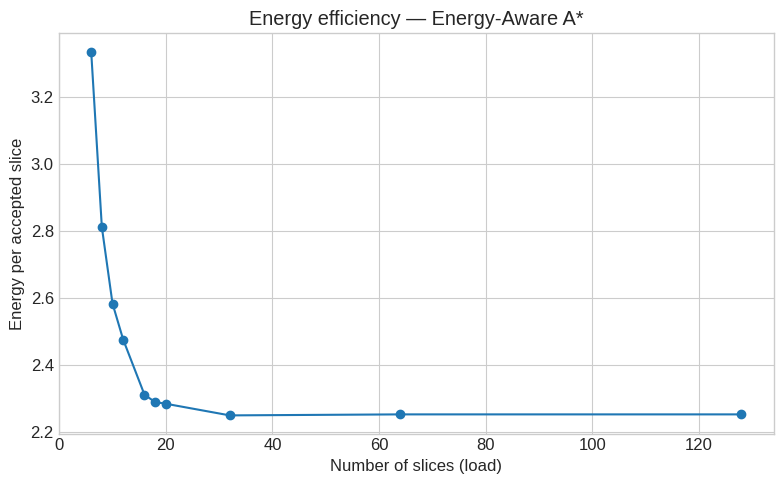

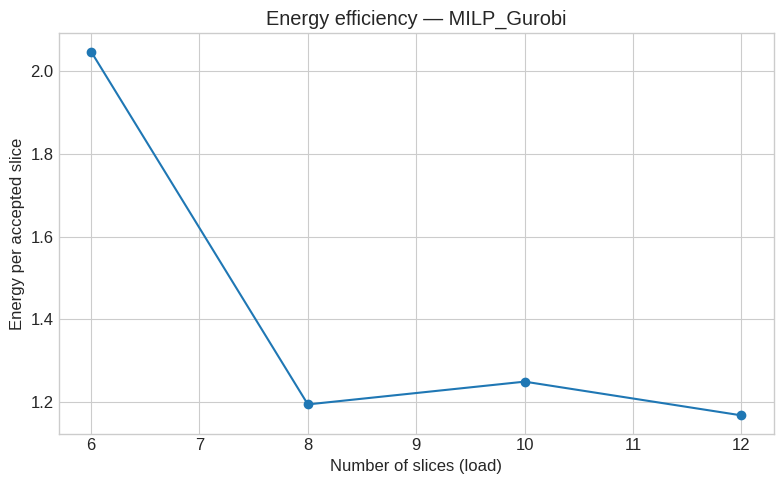

In [18]:
# ============================================
# One plot per method: energy per accepted slice
# ============================================
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

for method in methods_order:
    sub = df_results[df_results["method"] == method]
    sub = sub.dropna(subset=["energy_per_accepted_slice"])
    if sub.empty:
        continue

    grouped = (
        sub.groupby("num_slices")["energy_per_accepted_slice"]
           .mean()
           .reset_index()
           .sort_values("num_slices")
    )
    
    fig, ax = plt.subplots()
    ax.plot(
        grouped["num_slices"],
        grouped["energy_per_accepted_slice"],
        marker="o"
    )
    
    ax.set_xlabel("Number of slices (load)")
    ax.set_ylabel("Energy per accepted slice")
    ax.set_title(f"Energy efficiency — {method}")
    
    plt.tight_layout()
    plt.show()


In [19]:
# ============================================
# Ensure df_results and latest_dir are loaded
# ============================================

import os
import pandas as pd

if "df_results" not in globals() or "latest_dir" not in globals():
    print("[INFO] Loading latest results...")

    root = "./results"
    subdirs = [
        os.path.join(root, d)
        for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d))
    ]

    if not subdirs:
        raise RuntimeError("No results folders found under ./results")

    latest_dir = max(subdirs, key=os.path.getmtime)
    print("[INFO] Latest results directory:", latest_dir)

    results_path = os.path.join(latest_dir, "scalability_results.csv")
    print("[INFO] Loading:", results_path)

    df_results = pd.read_csv(results_path)

print("[INFO] Loaded df_results:", df_results.shape)


[INFO] Loaded df_results: (990, 14)


[INFO] Methods: ['A*' 'ABO' 'FABO' 'Best Fit' 'First Fit' 'Energy-Aware A*' 'MILP_Gurobi']
[INFO] Methods to plot (with errors): ['A*', 'ABO', 'FABO', 'Best Fit', 'First Fit', 'Energy-Aware A*', 'MILP_Gurobi']
[INFO] Chain lengths: [np.int64(2), np.int64(3), np.int64(4)]
[INFO] Figure saved to: ./results/2025-12-03_08-44-43/fig_energy_mean_with_errorbars/energy_mean_std_chainlen2.png


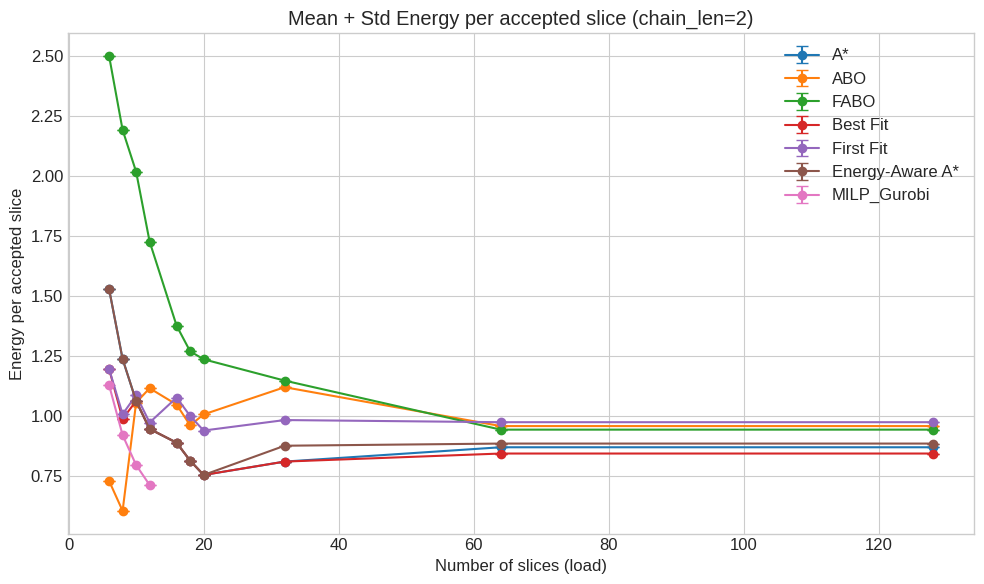

[INFO] Figure saved to: ./results/2025-12-03_08-44-43/fig_energy_mean_with_errorbars/energy_mean_std_chainlen3.png


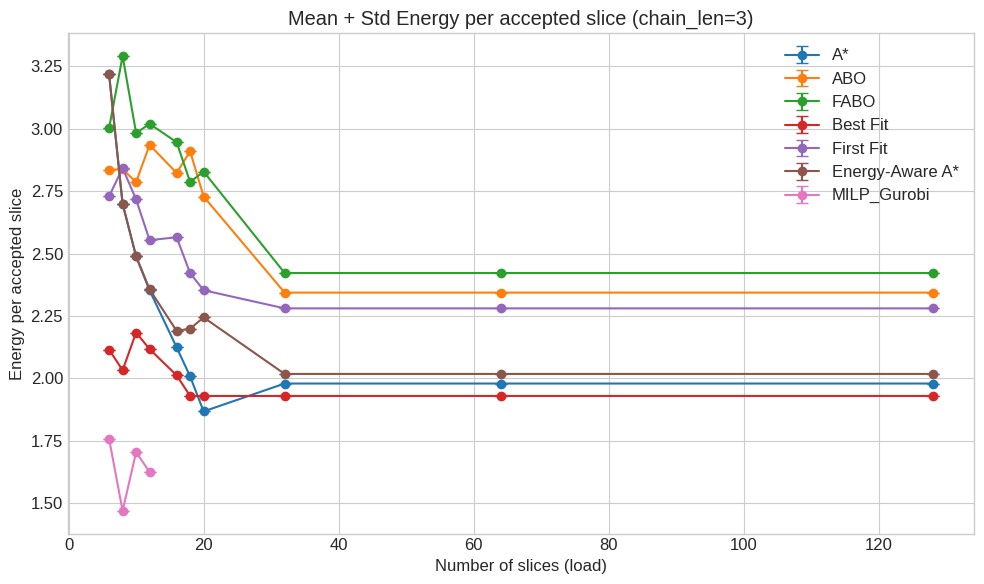

[INFO] Figure saved to: ./results/2025-12-03_08-44-43/fig_energy_mean_with_errorbars/energy_mean_std_chainlen4.png


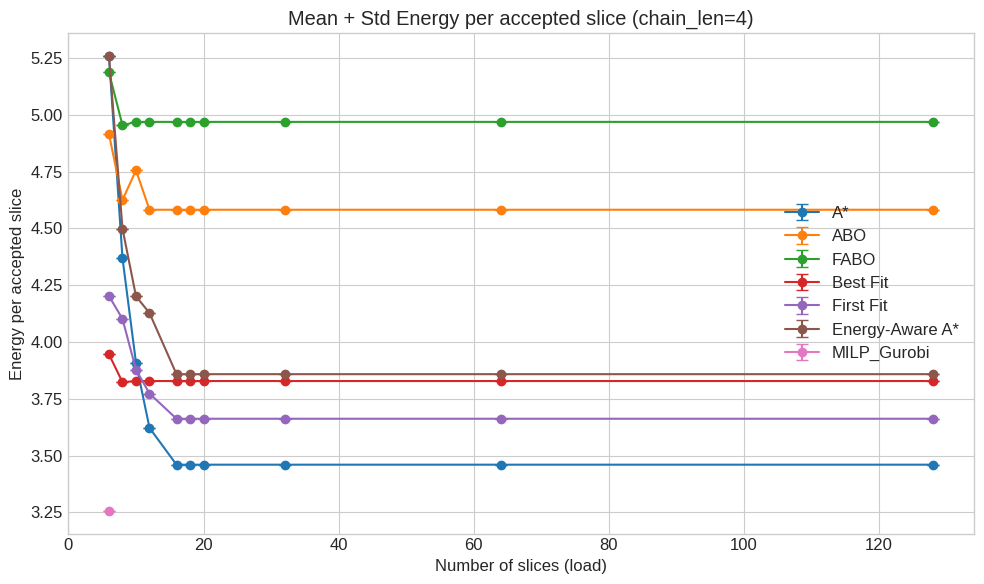

In [20]:
# ============================================
# Mean energy per accepted slice + error bars
# (std across seeds)
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Determine available methods automatically
available_methods = df_results["method"].unique()
print("[INFO] Methods:", available_methods)

# Preferred plot order
base_methods = [
    "A*", "ABO", "FABO",
    "Best Fit", "First Fit",
    "Energy-Aware A*",
]

# Only keep those that exist in df_results
methods_order = [m for m in base_methods if m in available_methods]

# Add MILP if present
milp_methods = [m for m in available_methods if "MILP" in m]
methods_order += milp_methods

print("[INFO] Methods to plot (with errors):", methods_order)

# Directory to save figures
fig_dir = os.path.join(latest_dir, "fig_energy_mean_with_errorbars")
os.makedirs(fig_dir, exist_ok=True)

chain_lengths = sorted(df_results["num_vnfs_per_slice"].unique())
print("[INFO] Chain lengths:", chain_lengths)

for chain_len in chain_lengths:
    plt.figure(figsize=(10, 6))

    mask = df_results["num_vnfs_per_slice"] == chain_len

    for method in methods_order:
        sub = df_results[mask & (df_results["method"] == method)]
        sub = sub.dropna(subset=["energy_per_accepted_slice"])

        if sub.empty:
            continue

        grouped = (
            sub.groupby("num_slices")["energy_per_accepted_slice"]
               .agg(["mean", "std"])
               .reset_index()
               .sort_values("num_slices")
        )

        x = grouped["num_slices"]
        y = grouped["mean"]
        yerr = grouped["std"]  # use std as error bar

        plt.errorbar(
            x, y, yerr=yerr,
            marker="o",
            capsize=4,
            label=method
        )

    plt.xlabel("Number of slices (load)")
    plt.ylabel("Energy per accepted slice")
    plt.title(f"Mean + Std Energy per accepted slice (chain_len={chain_len})")
    plt.legend()
    plt.tight_layout()

    # Save figure
    fig_path = os.path.join(fig_dir, f"energy_mean_std_chainlen{chain_len}.png")
    plt.savefig(fig_path, dpi=300)
    print(f"[INFO] Figure saved to: {fig_path}")

    plt.show()


NameError: name 'results_dir' is not defined

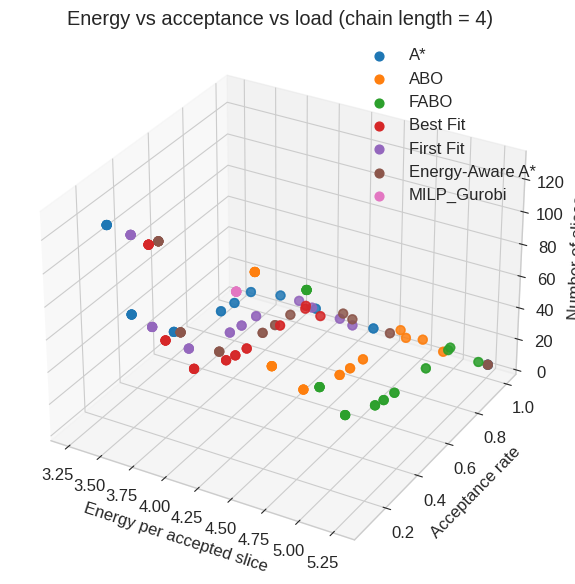

In [21]:
# ===========================================
# 3D plot: energy per accepted slice vs acceptance vs load
# ===========================================
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

df_3d = df_results.copy()
df_3d = df_3d.dropna(subset=["energy_per_accepted_slice"])

# Optional: focus on one chain length
chain_len = 4
df_3d = df_3d[df_3d["num_vnfs_per_slice"] == chain_len]

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

for method in methods_order:
    sub = df_3d[df_3d["method"] == method]
    if sub.empty:
        continue

    ax.scatter(
        sub["energy_per_accepted_slice"],
        sub["acceptance_rate"],
        sub["num_slices"],
        label=method,
        s=40,
    )

ax.set_xlabel("Energy per accepted slice")
ax.set_ylabel("Acceptance rate")
ax.set_zlabel("Number of slices")
ax.set_title(f"Energy vs acceptance vs load (chain length = {chain_len})")
ax.legend()
plt.tight_layout()

fig3d_path = os.path.join(results_dir, f"3d_energy_acceptance_vnfs{chain_len}.png")
plt.savefig(fig3d_path, dpi=300)
print(f"[INFO] 3D figure saved to: {fig3d_path}")

plt.show()


In [ ]:
# ===========================================
# Quick peek: best energy per scenario (same acceptance)
# ===========================================
cols = ["method", "num_slices", "num_vnfs_per_slice", "seed",
        "accepted", "acceptance_rate", "total_energy", "energy_per_accepted_slice"]

sample = (
    df_results[cols]
    .sort_values(["num_slices", "num_vnfs_per_slice", "seed",
                  "acceptance_rate", "total_energy"])
    .groupby(["num_slices", "num_vnfs_per_slice", "seed", "acceptance_rate"])
    .first()
    .reset_index()
)

display(sample.head(30))


,num_slices,num_vnfs_per_slice,seed,acceptance_rate,method,accepted,total_energy,energy_per_accepted_slice
0,4,2,1,1.0,ABO,4,3.9100,0.977500
1,4,2,2,1.0,ABO,4,3.9100,0.977500
2,4,2,3,1.0,ABO,4,3.9100,0.977500
3,4,2,4,1.0,ABO,4,3.9100,0.977500
4,4,2,5,1.0,ABO,4,3.9100,0.977500
5,4,3,1,1.0,Best Fit,4,7.0200,1.755000
6,4,3,2,1.0,Best Fit,4,7.0200,1.755000
7,4,3,3,1.0,Best Fit,4,7.0200,1.755000
8,4,3,4,1.0,Best Fit,4,7.0200,1.755000
9,4,3,5,1.0,Best Fit,4,7.0200,1.755000
